# prep

In [3]:
account_path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/'

In [4]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
from google.colab import auth
auth.authenticate_user()

# load packages - basics
!pip install pynrrd
import os
import csv
import numpy as np
import pandas as pd
import math
import time
import json
import nrrd

Mounted at /content/drive/


In [5]:
# load packages - stats
!pip install scikit-posthocs
import scipy
from scipy import io
from scipy.fftpack import rfft, irfft, fftfreq
import scipy.stats as stats
from scipy.stats import zscore

import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as scikit
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels

import random
from random import randrange, shuffle
import itertools
from itertools import combinations
import sklearn
from sklearn.decomposition import PCA, FastICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [6]:
# load packages - plotting and template settings
import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pickle

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## fcn.

In [7]:
import gspread
from google.auth import default

def read_metadata(gsheet_url,tab_name):
  """This script reads information in a tab in the Google sheet, where metadata for each experiment is stored.
  """
  # import gspread
  # from google.auth import default

  # reading in google sheet with experimental details
  creds, _ = default()
  gc = gspread.authorize(creds)

  # insert URl of gsheet, specify worksheets as different variables
  wb = gc.open_by_url(gsheet_url)
  exps = wb.worksheet(tab_name)

  #
  all_data = pd.DataFrame(exps.get_all_records())
  metadata = all_data.set_index('experiment')
  display(all_data)

  return metadata

In [8]:
from scipy.interpolate import interp1d
def resample_to_max_length(list_of_arrays):
    max_len = max(len(arr) for arr in list_of_arrays)
    resampled = []
    for arr in list_of_arrays:
        x_old = np.linspace(0, 1, len(arr))
        x_new = np.linspace(0, 1, max_len)
        f = interp1d(x_old, arr, kind='linear', fill_value='extrapolate')
        resampled.append(f(x_new))
    return np.array(resampled), max_len

## config

In [9]:
# figures output parameters
mpl.rcParams['lines.linewidth'] = 1        # default line width
mpl.rcParams['patch.linewidth'] = 0
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# Set global Matplotlib parameters for PDF output
mpl.rcParams['pdf.fonttype'] = 42          # Use TrueType fonts (editable text)

mpl.rcParams['figure.figsize'] = (4,3)     # Default figure size in inches
mpl.rcParams['axes.titlesize'] = 16        # Title font size
mpl.rcParams['axes.labelsize'] = 14        # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10       # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10       # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 8        # Legend font size
mpl.rcParams['savefig.dpi'] = 300          # DPI for high-quality export (relevant for raster elements)
mpl.rcParams['savefig.transparent'] = True # Ensures background is transparent
sns.set(style="white",font_scale=1)     # global scaling of all texts
mpl.rcParams['xtick.bottom'] = True        # make sure ticks visible
mpl.rcParams['ytick.left'] = True

mpl.rcParams['xtick.major.width'] = 0.5    # X-axis major tick width
mpl.rcParams['ytick.major.width'] = 0.5    # Y-axis major tick width
mpl.rcParams['axes.linewidth'] = 0.5       # Axis line width

from cycler import cycler
# remove red from the default colors
mpl.rcParams['axes.prop_cycle'] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [10]:
figure_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/'
csv_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/csvs/'

# Data (fish do stuff)

In [11]:
# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1tpUkPiWTz_j2fthNLOIQvooPCbYnScKaoHLthi5yq18/edit?gid=106031496#gid=106031496'
tab_name = 'fish_stim'

path = account_path + 'Yu_escape_paper/Imaging/Fish_do_stuff/'
data_path = path + 'Data/'
save_path = path + 'Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index
fcn_files = metadata.fcn_file
planeNum = metadata.planeNum
trialNum = metadata.trialNum

,experiment,fcn_file,planeNum,trialNum
0,jy-260210-f1,t3-stimL_trim,1,4 4 4 3 4
1,jy-260210-f2,t3-stimR_trim,1,5 5 5 5 5
2,jy-260218-f1,t1-stimR_trim,1,5 6 5 6 7
3,jy-260218-f1,t2-stimR,1,10 10 10 10 10
4,jy-260218-f1,t3-stimR,1,10 10 10 10 10
5,jy-260218-f1,t4-stimR,1,10 10 10 10 10
6,jy-260218-f2,t1-stimL_trim,1,10 10 10 10 10
7,jy-260218-f2,t2-stimL,1,10 10 10 10 10
8,jy-260218-f2,t3-stimL,1,10 10 10 10 10
9,jy-260218-f2,t4-stimL,1,10 10 10 10 10


## stim type color scheme

In [12]:
# establish stim type num, names, and colors
resample_Hz = 10
pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
event = 5*resample_Hz # potential response window to offset of stimulus
trial_len = pre+stim_dur+post

stim_names = ['BM-escape','BM-disappear','Linear-escape','Linear-disappear','BM-loom']
stim_colorz = ['darkorange','chocolate','teal','darkslategrey','maroon']

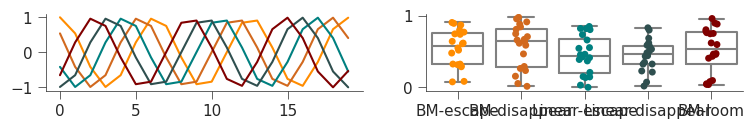

In [13]:
group_num = len(stim_names); group_names = stim_names
tmp = {n: np.random.random(20) for n in stim_names};

# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=stim_colorz[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=stim_colorz); sns.despine();
plt.show()

# 5a - fish stimuli

# 5b - example single cell traces

fish # jy-260218-f2 :  t1-stimL_trim
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/5b


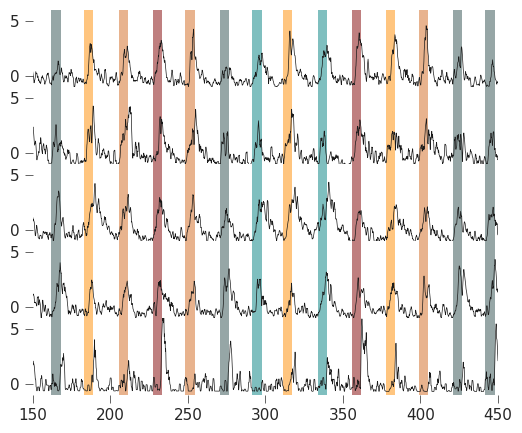

,cell_1,cell_2,cell_3,cell_4,cell_5,BM-escape_on,BM-escape_off,BM-disappear_on,BM-disappear_off,Linear-escape_on,Linear-escape_off,Linear-disappear_on,Linear-disappear_off,BM-loom_on,BM-loom_off
0,0.280780,2.275362,1.098420,1.032768,1.847624,183.1,189.1,205.3,211.3,119.9,125.9,162.0,168.0,141.1,147.1
1,0.165609,2.353493,1.081453,1.067696,2.073935,311.5,317.5,248.5,254.5,291.6,297.6,270.5,276.5,227.4,233.4
2,0.048365,2.242512,0.947714,1.129418,1.938052,377.8,383.8,398.9,404.9,333.7,339.7,421.0,427.0,355.8,361.8
3,-0.035021,2.088420,0.854110,1.165003,1.780319,482.2,488.2,525.3,531.3,504.2,510.2,442.0,448.0,462.1,468.1
4,-0.054584,1.990245,0.904723,1.121496,1.825496,590.7,596.7,612.7,618.7,568.4,574.4,546.4,552.4,633.8,639.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,-0.624093,-0.275549,0.570129,1.596831,3.952515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2996,-0.550229,-0.260548,0.474082,1.635435,3.746725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2997,-0.575251,-0.262057,0.093754,1.505215,3.416071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2998,-0.610895,-0.341434,-0.233057,1.386186,3.035145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
subpanel = '5b'

rep_exp_ffile = ['jy-260218-f2,t1-stimL_trim']

pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
trial_len = pre+stim_dur+post

samples=[] # initiate for saving source data
for rep_exp in rep_exp_ffile:
  rep_exp, rep_ffile = rep_exp.split(',')
  for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
    if exp != rep_exp or ffile != rep_ffile: continue
    load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
    print("fish #", exp, ': ', ffile)

    # load processed data
    data = np.load(load_path+'neuron_details.npz', allow_pickle=True)
    traces_Z = data['traces_Z']
    # load stimulus onsets
    with open(load_path+'stim_ON.pkl', 'rb') as f:
      stim_on = pickle.load(f) # len(stim_names) x [n for f in trial_num]
    # load correlation coefficients
    data = np.load(output_path+'corrcoeff.npz',allow_pickle=True)
    corr = data['corr']

    # make time in sec
    frame_num = traces_Z.shape[1]
    time_sec = np.arange(frame_num)/resample_Hz

    #  vis
    fig, axs = plt.subplots(len(stim_names),1,figsize=(6,5))
    for id in range(len(stim_names)):
      max_corr = np.max(corr[id]); max_cell = np.argmax(corr[id])
      plt.subplot(len(stim_names),1,id+1)
      plt.plot(time_sec,traces_Z[max_cell], 'k',lw=0.5); samples.append(traces_Z[max_cell])
      plt.ylim(-1,6); # ylim = plt.ylim();
      sns.despine(bottom=True, left=True)
      if id != len(stim_names)-1: plt.xticks([])
      for j in range(len(stim_names)):
        on_frames = [on/resample_Hz for on in stim_on[j]]
        off_frames = [(on+stim_dur)/resample_Hz for on in stim_on[j]]
        for on, off in zip(on_frames,off_frames): plt.axvspan(on,off,facecolor=stim_colorz[j],alpha=0.5,edgecolor='none')
      plt.xlim(150,450)
    plt.subplots_adjust(hspace=0)
    print(figure_path+subpanel)
    # plt.savefig(figure_path+subpanel+'.pdf',bbox_inches='tight')
    plt.show()

    # save source data into csv - for time series, save out the visible part
    ST, ED = 0, traces_Z.shape[1]/resample_Hz; st, ed = 150, 450; fps = resample_Hz

    series_dict = {}
    for i, sample in enumerate(samples):
      col_name = f"cell_{i+1}"
      series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])  # auto-fills NaN

    for i, stim_name in enumerate(stim_names):
      col_name = f"{stim_name}_on"; series_dict[col_name] = pd.Series([on/resample_Hz for on in stim_on[i]])
      col_name = f"{stim_name}_off"; series_dict[col_name] = pd.Series([(on+stim_dur)/resample_Hz for on in stim_on[i]])

    df = pd.DataFrame(series_dict)
    display(df)
    df.to_csv(csv_path+subpanel+'.csv', index=False)

# 5c - exmaple rastermap

In [ ]:
!pip install rastermap
from rastermap import Rastermap, utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.5/90.5 kB 6.8 MB/s eta 0:00:00


fish # jy-260218-f3 :  t2-stimR_trim
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/5c


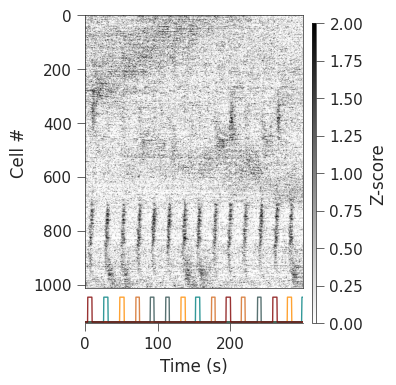

,cell_0,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,...,cell_1010,cell_1011,cell_1012,cell_1013,cell_1014,stim_1,stim_2,stim_3,stim_4,stim_5
0,0.198207,2.699395,2.273666,2.310992,-0.071916,0.105890,-0.420932,-0.256460,-1.053128,-0.576124,...,0.275763,1.811858,-1.305617,-1.217226,0.009636,0.0,0.0,0.0,0.0,0.0
1,0.187144,2.410105,1.715629,2.293262,0.059994,0.166641,-0.732132,-0.106724,-1.103297,-0.747569,...,0.335223,1.483050,-1.245819,-1.216981,0.589031,0.0,0.0,0.0,0.0,0.0
2,0.091064,1.982951,1.528598,2.225940,0.090376,0.173698,-1.091478,-0.052564,-1.197641,-1.052495,...,0.409234,1.398794,-1.201811,-1.216736,0.872543,0.0,0.0,0.0,0.0,0.0
3,-0.044673,1.581462,1.533770,2.214442,-0.003718,0.115422,-1.244105,-0.067604,-1.217240,-1.236495,...,0.484298,1.383637,-1.193557,-1.216492,0.954734,0.0,0.0,0.0,0.0,0.0
4,-0.188431,1.377854,1.557740,2.304667,-0.235068,-0.043384,-1.026085,-0.137308,-1.080254,-1.137789,...,0.540417,1.321001,-1.214002,-1.216247,0.881806,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,-0.382484,-0.552544,-0.892859,0.397915,-1.470476,-0.899778,-1.180233,0.520355,-0.781513,-0.611749,...,2.041864,0.234779,-1.464192,-0.484262,1.010948,0.0,0.0,1.0,0.0,0.0
2996,-0.519786,-0.591398,-0.778907,0.303868,-1.462112,-0.579324,-0.952697,0.784034,-0.740882,-0.052734,...,1.932446,0.385245,-1.404313,-0.484017,1.171148,0.0,0.0,1.0,0.0,0.0
2997,-0.959703,-0.731568,-0.490082,0.321895,-1.440783,-0.530472,-0.865301,1.072118,-0.913832,0.385335,...,1.814245,0.498707,-1.409864,-0.483773,0.760724,0.0,0.0,1.0,0.0,0.0
2998,-1.098435,-0.802630,-0.258128,0.409903,-1.370790,-0.605119,-0.886240,1.219344,-1.025904,0.629620,...,1.613726,0.584157,-1.441448,-0.483528,0.320383,0.0,0.0,1.0,0.0,0.0


In [ ]:
subpanel = '5c'

rep_exp_ffile = ['jy-260218-f3,t2-stimR_trim']

pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
trial_len = pre+stim_dur+post

for rep_exp in rep_exp_ffile:
  rep_exp, rep_ffile = rep_exp.split(',')
  for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
    if exp != rep_exp or ffile != rep_ffile: continue
    load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
    print("fish #", exp, ': ', ffile)

    # load processed 2p info
    data = np.load(load_path+'neuron_details.npz', allow_pickle=True)
    traces_Z, xs, ys, zs = data['traces_Z'], data['xs'], data['ys'], data['zs']
    # load stimulus
    data = np.load(load_path+'regressors.npz', allow_pickle=True)
    stimuli = data['stimuli']

    # load cell selection
    data = np.load(output_path+'ttest_5-8_cells.npz', allow_pickle=True)
    cell_id, resp_arr = data['cell_id'], data['resp_arr']

    # make time in sec
    frame_num = traces_Z.shape[1]
    time_sec = np.arange(frame_num)/resample_Hz

    # crop the last 300 sec
    traces_Z = traces_Z[cell_id,-400*resample_Hz:-100*resample_Hz]
    time_sec = time_sec[:300*resample_Hz];

    # vis
    # fit rastermap to pca clustering
    spks = np.array(traces_Z) # neurons x timepoints
    model = Rastermap(n_clusters=10, n_PCs=10, time_lag_window=10, locality=0.5,\
                      grid_upsample=10).fit(spks)
    clu_neuron = model.embedding; isort = model.isort # indices to sort traces into cluster

    # plot
    fig, axs = plt.subplots(2,1, figsize=(3,4), gridspec_kw={'height_ratios':[10,1]}) # 'width_ratios': [10,1]
    im = axs[0].imshow(spks[isort, :], cmap="gray_r", vmin=0, vmax=2, aspect="auto")
    axs[0].set_xticks([]); axs[0].set_ylabel('Cell #');
    fig.subplots_adjust(right=0.85,wspace=0.05)
    cbar_ax = fig.add_axes([0.88,0.11,0.015,0.75])  # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cbar_ax, label='Z-score');
    for idx, stim in enumerate(stimuli):
      axs[1].plot(time_sec,stim[-400*resample_Hz:-100*resample_Hz], color=stim_colorz[idx], linewidth=1, alpha=0.8)
    axs[1].spines['top'].set_visible(False); axs[1].spines['right'].set_visible(False)
    axs[1].spines['left'].set_visible(False); axs[1].set_xlabel('Time (s)')
    axs[1].set_yticks([]); axs[1].set_xlim(0,time_sec[-1])
    plt.subplots_adjust(hspace=0.05)
    print(figure_path+subpanel)
    plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
    plt.show()

    # save source data into csv
    series_dict = {}
    for idx, trace in enumerate(spks[isort, :]): series_dict['cell_'+str(idx)] = trace
    for idx, stim in enumerate(stimuli): series_dict['stim_'+str(idx+1)] = pd.Series(stim[-400*resample_Hz:-100*resample_Hz])

    df = pd.DataFrame(series_dict)
    display(df)
    df.to_csv(csv_path+subpanel+'.csv', index=False)

# 5d - exmaple heatmap

In [ ]:
# Install required package
!pip install upsetplot
from upsetplot import from_contents, UpSet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24864 sha256=c9c30036d29c03f435393f18d958586fe2198978654e21f90beba002e6e6cfeb
  Stored in directory: /root/.cache/pip/wheels/5d/7a/54/1460364da0fe4e17c256b7a28191fa373d81292fcf73a4ddb8
Successfully built upsetplot


fish # jy-260218-f3 :  t4-stimR_trim1
responsive celss n = [278, 267, 265, 272, 279]

 any responsive cells
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/5d


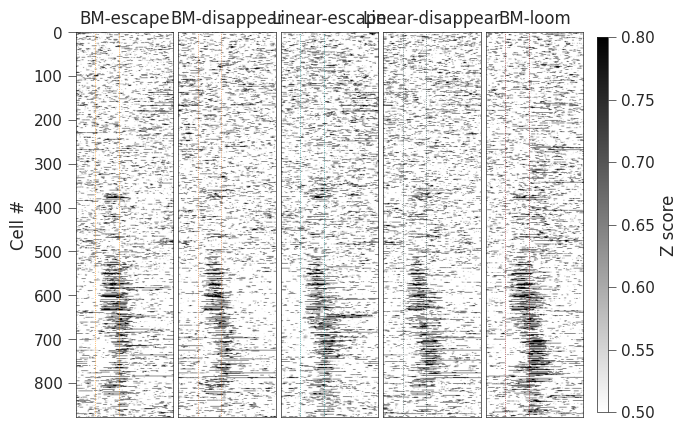

total (unique) n = 878


,cell_1_to_BM-escape,cell_2_to_BM-escape,cell_3_to_BM-escape,cell_4_to_BM-escape,cell_5_to_BM-escape,cell_6_to_BM-escape,cell_7_to_BM-escape,cell_8_to_BM-escape,cell_9_to_BM-escape,cell_10_to_BM-escape,...,cell_869_to_BM-loom,cell_870_to_BM-loom,cell_871_to_BM-loom,cell_872_to_BM-loom,cell_873_to_BM-loom,cell_874_to_BM-loom,cell_875_to_BM-loom,cell_876_to_BM-loom,cell_877_to_BM-loom,cell_878_to_BM-loom
0,-0.668026,1.348339,0.226761,-0.312269,-0.150601,0.698900,0.708790,0.776941,-0.105103,-0.385843,...,-0.684599,-0.079495,-0.481848,-0.872328,-0.054206,-0.067740,0.626546,-0.553811,-0.021334,-0.298727
1,-0.512445,1.518792,0.457784,-0.168642,-0.251506,0.744206,0.531309,0.587135,0.007113,-0.348968,...,-0.706176,-0.178439,-0.417101,-0.681711,-0.201357,-0.091741,0.834945,-0.553862,-0.018261,-0.404026
2,-0.136329,1.669520,0.676500,0.041662,-0.330347,0.812747,0.300908,0.351560,-0.062076,-0.317645,...,-0.765941,-0.167127,-0.320422,-0.507118,-0.408587,-0.189684,1.094913,-0.553914,-0.112256,-0.397121
3,0.107682,1.540978,0.894342,0.299094,-0.303472,0.931370,0.062146,0.188274,-0.206638,-0.413526,...,-0.797836,-0.035447,-0.242511,-0.455381,-0.516101,-0.191802,1.414788,-0.553966,-0.140240,-0.437658
4,0.121012,1.156587,1.050610,0.573455,-0.184925,1.109090,-0.147150,0.003717,-0.326956,-0.560840,...,-0.780191,0.203844,-0.179619,-0.437817,-0.506636,-0.101089,1.723638,-0.543781,-0.115093,-0.553366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.788887,1.329158,-0.533579,-0.384912,0.410281,-0.038040,0.599700,0.103766,0.099671,0.375399,...,0.671552,-1.122030,0.721139,-0.241278,-0.626820,-0.332800,-0.308763,-0.409370,0.183863,-0.369351
246,0.601177,1.465679,-0.527091,-0.528088,0.407435,-0.126723,0.316779,0.027105,0.048622,0.511447,...,0.678938,-1.030026,0.759773,-0.170311,-0.778770,-0.079162,-0.270228,-0.467348,0.133378,-0.440215
247,0.300270,1.449046,-0.493959,-0.449910,0.313610,-0.256973,0.073469,-0.036654,-0.032256,0.567500,...,0.684612,-0.888555,0.738259,-0.091007,-0.848428,0.088153,-0.282358,-0.304375,0.117808,-0.470117
248,0.216726,1.347400,-0.419876,-0.199677,0.055711,-0.378659,-0.144391,-0.060979,-0.091468,0.530824,...,0.727604,-0.670649,0.640849,-0.112550,-0.842801,0.075593,-0.371997,-0.011033,0.167657,-0.496226


In [ ]:
subpanel = '5d'

rep_exp_ffile = ['jy-260218-f3,t4-stimR_trim1'] # ['jy-260218-f3,t3-stimR_trim'] #['jy-260218-f1,t1-stimR_trim']
#'jy-260218-f3 : t3-stimR_trim', 'jy-260218-f3 : t4-stimR_trim1'

pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus
trial_len = pre+stim_dur+post

for rep_exp in rep_exp_ffile:
  rep_exp, rep_ffile = rep_exp.split(',')
  for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
    if exp != rep_exp or ffile != rep_ffile: continue
    load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
    print("fish #", exp, ': ', ffile)
    # (1) get cell respnse metrics
    data = np.load(output_path+'ttest_5-8.npz', allow_pickle=True)
    Pval_long = data['Pval']
    # categorize responsive or not
    all_profile = np.array([p<0.05 for p in Pval_long]) # resp profile of all cells
    resp_arr = all_profile[:,np.any(all_profile,axis=0)] # resp profiles of all responsive cells
    # get cell ids
    cell_ids = np.arange(Pval_long.shape[1])
    resp_ids = [cell_ids[p<0.05] for p in Pval_long] # list of responsive cell id for each stim
    cell_arr = np.unique(np.concatenate(resp_ids)) # list of cell id resp to any stim

    print('responsive celss n =', [len(c) for c in resp_ids])
    # compute & visualize overlap of response
    tmp = {stim: cells for stim, cells in zip(stim_names, resp_ids)}
    overlap = from_contents(tmp);
    plt.show()

    # load PSTHs
    with open(output_path+'PSTHs.pkl', 'rb') as f:
      PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

    print('\n any responsive cells')
    resp_raster = [[] for i in range(len(stim_names))] # use cell_arr # non-repeating
    for id in range(len(stim_names)):
      for icell in cell_arr: resp_raster[id].append(np.nanmean(PSTHs[icell][id],axis=0))
    resp_raster = np.array(resp_raster); #print(resp_raster.shape)

    #  rastermap
    fig,_ = plt.subplots(1,len(stim_names),figsize=[7,5]) # [10,6]
    for istim in range(len(stim_names)):
      box = np.array(resp_raster[istim])
      plt.subplot(1,len(stim_names),istim+1)
      im = plt.imshow(box, cmap="gray_r", vmin=0.5, vmax=0.8, aspect="auto")
      plt.title(stim_names[istim])
      for line in [pre, pre+stim_dur]: plt.axvline(line,c=stim_colorz[istim],linestyle=':',lw=0.5); plt.xticks([])
      if istim==0: plt.ylabel('Cell #')
      if istim>0: plt.yticks([])
    fig.subplots_adjust(right=0.85,wspace=0.05)
    cbar_ax = fig.add_axes([0.87,0.12,0.015,0.75])  # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cbar_ax, label='Z score'); # cbar.ax.tick_params(left=False, labelleft=False)  # Remove ticks and labels
    print(figure_path+subpanel)
    plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
    plt.show()

    print(f"total (unique) n = {len(cell_arr)}")

    # save source data into csv
    series_dict = {}
    for istim, sample in enumerate(resp_raster):
      for icell, psth in enumerate(sample):
        col_name = f"cell_{icell+1}_to_{stim_names[istim]}"
        series_dict[col_name] = pd.Series(psth)

    df = pd.DataFrame(series_dict)
    display(df)
    df.to_csv(csv_path+subpanel+'.csv', index=False)

# 5e-g SVM time series

## 5e - BM vs LM

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/5e


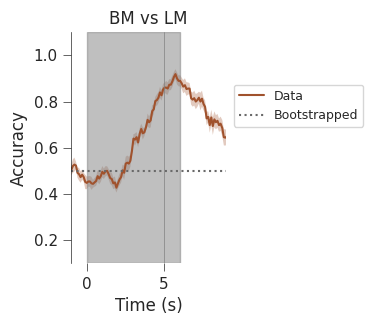

,data_0,data_1,data_2,data_3,data_4,data_5,data_6,data_7,data_8,data_9,...,bootstrapped_5,bootstrapped_6,bootstrapped_7,bootstrapped_8,bootstrapped_9,bootstrapped_10,bootstrapped_11,bootstrapped_12,bootstrapped_13,bootstrapped_14
0,0.56250,0.53125,0.34375,0.56250,0.56250,0.40625,0.46875,0.43750,0.34375,0.62500,...,0.49250,0.49875,0.50500,0.49000,0.51250,0.51125,0.49750,0.52250,0.52250,0.49375
1,0.59375,0.53125,0.34375,0.53125,0.65625,0.46875,0.53125,0.37500,0.34375,0.68750,...,0.48000,0.48875,0.49125,0.50375,0.50125,0.51750,0.51125,0.50250,0.49000,0.51375
2,0.65625,0.59375,0.40625,0.53125,0.65625,0.50000,0.53125,0.40625,0.50000,0.65625,...,0.52750,0.49750,0.50250,0.49750,0.52000,0.50125,0.46875,0.51625,0.51625,0.49875
3,0.81250,0.56250,0.53125,0.56250,0.56250,0.43750,0.62500,0.40625,0.40625,0.68750,...,0.49375,0.49250,0.49375,0.48500,0.47250,0.48625,0.48500,0.50500,0.49375,0.50250
4,0.75000,0.50000,0.56250,0.53125,0.59375,0.43750,0.53125,0.40625,0.46875,0.75000,...,0.51000,0.55000,0.50250,0.50250,0.50625,0.48125,0.48250,0.50000,0.48000,0.52250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.53125,0.31250,0.40625,0.40625,0.46875,0.40625,0.43750,0.40625,0.56250,0.62500,...,0.51125,0.50750,0.48000,0.49750,0.49375,0.47500,0.50250,0.50500,0.49500,0.47375
246,0.53125,0.34375,0.40625,0.40625,0.53125,0.50000,0.43750,0.46875,0.40625,0.56250,...,0.49125,0.50875,0.48625,0.52500,0.49000,0.52875,0.48625,0.51750,0.47500,0.48375
247,0.50000,0.31250,0.40625,0.40625,0.46875,0.59375,0.40625,0.56250,0.40625,0.50000,...,0.49875,0.51000,0.50875,0.53500,0.48250,0.48250,0.53000,0.51250,0.49125,0.49500
248,0.43750,0.40625,0.53125,0.40625,0.43750,0.56250,0.37500,0.53125,0.43750,0.46875,...,0.46000,0.49500,0.49750,0.51125,0.51875,0.52000,0.50500,0.52375,0.50000,0.51375


In [17]:
subpanel = '5e'
decoder = 'svm_BM_LM'; decoder_name = 'BM vs LM'

Real, Bootstrapped = [], []
for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  [t1, t2, t3, t4,t5] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  if np.sum([t>=8 for t in [t1,t2,t3,t4,t5]])!=5: continue
  with open(output_path+'Decoders/'+decoder+'.pkl','rb') as f: data = pickle.load(f)

  # n_neurons, n_components, n_trials = data['n_neurons'], data['n_components'], data['n_trials']
  real_inst, perm_inst = data['real_inst'], data['perm_inst']

  Real.append(real_inst)
  Bootstrapped.append(perm_inst)

# make time to
rel_time = np.linspace(-5,20,25*resample_Hz); rel_sec = np.round(rel_time,2)

# Visualization
plt.figure(figsize=[2,3])
mean1, sem1 = np.mean(Real, axis=0), stats.sem(Real, axis=0)
mean2, sem2 = np.mean(Bootstrapped, axis=0), stats.sem(Bootstrapped, axis=0)

plt.plot(rel_sec, mean1, 'sienna', label='Data')
plt.fill_between(rel_sec, mean1+sem1, mean1-sem1, alpha=0.3, color='sienna',lw=0)
plt.axvline(5, color='gray',lw=0.5);
plt.axhline(np.nanmean(mean2), color='dimgrey',ls=':', label='Bootstrapped')
plt.axvspan(0,6, color='gray',alpha=0.5);
plt.xlim(-1,9); plt.xlabel('Time (s)')
plt.legend(fontsize=9, bbox_to_anchor=(1.01, 0.8)); sns.despine(bottom=True)
plt.ylabel('Accuracy'); plt.title(decoder_name); plt.ylim(0.1,1.1)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, d in enumerate(Real): series_dict['data_'+str(i)] = pd.Series(d)
for i, d in enumerate(Bootstrapped): series_dict['bootstrapped_'+str(i)] = pd.Series(np.mean(d,axis=0))
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f".csv", index=False)

## 5f - BM-escp vs BM-escp

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/5f


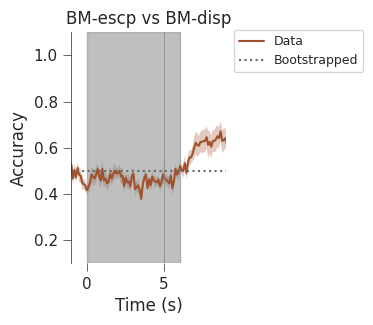

,data_0,data_1,data_2,data_3,data_4,data_5,data_6,data_7,data_8,data_9,...,bootstrapped_5,bootstrapped_6,bootstrapped_7,bootstrapped_8,bootstrapped_9,bootstrapped_10,bootstrapped_11,bootstrapped_12,bootstrapped_13,bootstrapped_14
0,0.3125,0.5625,0.4375,0.6250,0.4375,0.5625,0.4375,0.3125,0.4375,0.5000,...,0.4725,0.5125,0.4675,0.5025,0.5000,0.4875,0.5425,0.5275,0.4875,0.5125
1,0.5000,0.6875,0.3750,0.5625,0.4375,0.6250,0.4375,0.1875,0.5000,0.3750,...,0.5275,0.4675,0.5025,0.4675,0.5175,0.5125,0.4950,0.5000,0.5125,0.5075
2,0.5000,0.6875,0.3125,0.4375,0.3125,0.6875,0.4375,0.2500,0.3750,0.5625,...,0.5175,0.5000,0.5300,0.5225,0.4900,0.5075,0.5025,0.4925,0.4650,0.4500
3,0.5000,0.6250,0.2500,0.4375,0.5000,0.5000,0.4375,0.3125,0.3750,0.5625,...,0.4975,0.4875,0.4825,0.4925,0.4800,0.4900,0.5025,0.4950,0.5150,0.5050
4,0.4375,0.5625,0.4375,0.5000,0.3750,0.5625,0.4375,0.3750,0.5000,0.4375,...,0.5175,0.4925,0.5175,0.4850,0.5000,0.4700,0.5125,0.4950,0.5150,0.5025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.6250,0.6250,0.5625,0.3125,0.4375,0.3125,0.6250,0.5000,0.5625,0.5625,...,0.5375,0.5075,0.5325,0.4900,0.5175,0.4925,0.4850,0.4850,0.5025,0.4825
246,0.5625,0.5625,0.5625,0.3125,0.5625,0.4375,0.5000,0.4375,0.5000,0.6250,...,0.4975,0.5275,0.4925,0.4950,0.4925,0.5075,0.5700,0.4950,0.4500,0.4975
247,0.6250,0.5625,0.6875,0.2500,0.5625,0.4375,0.4375,0.5625,0.6875,0.5625,...,0.4900,0.4900,0.5625,0.5200,0.5150,0.5100,0.5200,0.4675,0.4875,0.5175
248,0.6875,0.5625,0.7500,0.3125,0.5000,0.3750,0.5625,0.4375,0.6875,0.5000,...,0.5200,0.5050,0.5025,0.5100,0.4625,0.5000,0.4525,0.5075,0.5025,0.4925


In [18]:
subpanel = '5f'
decoder = 'svm_BM_escp_disp'; decoder_name = 'BM-escp vs BM-disp'

Real, Bootstrapped = [], []
for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  [t1, t2, t3, t4,t5] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  if np.sum([t>=8 for t in [t1,t2,t3,t4,t5]])!=5: continue
  with open(output_path+'Decoders/'+decoder+'.pkl','rb') as f: data = pickle.load(f)

  # n_neurons, n_components, n_trials = data['n_neurons'], data['n_components'], data['n_trials']
  real_inst, perm_inst = data['real_inst'], data['perm_inst']

  Real.append(real_inst)
  Bootstrapped.append(perm_inst)

# make time to
rel_time = np.linspace(-5,20,25*resample_Hz); rel_sec = np.round(rel_time,2)

# Visualization
plt.figure(figsize=[2,3])
mean1, sem1 = np.mean(Real, axis=0), stats.sem(Real, axis=0)
mean2, sem2 = np.mean(Bootstrapped, axis=0), stats.sem(Bootstrapped, axis=0)

plt.plot(rel_sec, mean1, 'sienna', label='Data')
plt.fill_between(rel_sec, mean1+sem1, mean1-sem1, alpha=0.3, color='sienna',lw=0)
plt.axvline(5, color='gray',lw=0.5);
plt.axhline(np.nanmean(mean2), color='dimgrey',ls=':', label='Bootstrapped')
plt.axvspan(0,6, color='gray',alpha=0.5);
plt.xlim(-1,9); plt.xlabel('Time (s)')
plt.legend(fontsize=9, bbox_to_anchor=(1.01, 0.8)); sns.despine(bottom=True)
plt.ylabel('Accuracy'); plt.title(decoder_name); plt.ylim(0.1,1.1)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, d in enumerate(Real): series_dict['data_'+str(i)] = pd.Series(d)
for i, d in enumerate(Bootstrapped): series_dict['bootstrapped_'+str(i)] = pd.Series(np.mean(d,axis=0))
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f".csv", index=False)

## 5g - BM-escp vs BM-loom

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/5g


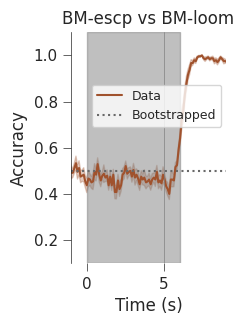

,data_0,data_1,data_2,data_3,data_4,data_5,data_6,data_7,data_8,data_9,...,bootstrapped_5,bootstrapped_6,bootstrapped_7,bootstrapped_8,bootstrapped_9,bootstrapped_10,bootstrapped_11,bootstrapped_12,bootstrapped_13,bootstrapped_14
0,0.5000,0.6875,0.5000,0.5000,0.5000,0.4375,0.4375,0.5000,0.3125,0.4375,...,0.5200,0.5175,0.5050,0.4925,0.5100,0.5000,0.5450,0.5000,0.5025,0.5050
1,0.4375,0.5625,0.6875,0.5625,0.5000,0.4375,0.5625,0.4375,0.3750,0.4375,...,0.5375,0.5075,0.4925,0.5000,0.5175,0.4875,0.5400,0.4750,0.5125,0.4950
2,0.3750,0.6875,0.5000,0.5625,0.5000,0.5000,0.5000,0.3750,0.2500,0.6875,...,0.5075,0.4975,0.5125,0.5000,0.5200,0.4875,0.5075,0.4925,0.4900,0.4775
3,0.3750,0.6875,0.5625,0.4375,0.5000,0.5000,0.6250,0.3750,0.4375,0.6875,...,0.4975,0.5075,0.5150,0.5050,0.4950,0.5175,0.5175,0.5250,0.5025,0.4925
4,0.3750,0.6250,0.5625,0.3750,0.6250,0.5000,0.6250,0.6250,0.3750,0.6250,...,0.4925,0.4925,0.4925,0.5150,0.5050,0.4925,0.4725,0.5000,0.5125,0.4875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.7500,0.6875,0.6875,0.5000,0.6250,0.6875,0.5000,0.6250,0.5000,0.5625,...,0.4750,0.5025,0.4650,0.4925,0.5050,0.5175,0.4825,0.5275,0.4925,0.4975
246,0.7500,0.6875,0.6875,0.3750,0.5000,0.6250,0.5000,0.5625,0.5625,0.7500,...,0.5275,0.5275,0.5200,0.4600,0.4825,0.5050,0.4975,0.4950,0.5350,0.5025
247,0.7500,0.6250,0.6250,0.4375,0.5625,0.6250,0.6250,0.5000,0.4375,0.7500,...,0.5050,0.5125,0.4925,0.4950,0.5025,0.5025,0.4675,0.5325,0.4775,0.4825
248,0.8125,0.8125,0.7500,0.3750,0.3750,0.5000,0.4375,0.5625,0.3750,0.5625,...,0.4850,0.5175,0.5250,0.4825,0.4875,0.4875,0.5125,0.4950,0.4525,0.4900


In [19]:
subpanel = '5g'
decoder = 'svm_BM_escp_loom'; decoder_name = 'BM-escp vs BM-loom'

Real, Bootstrapped = [], []
for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  [t1, t2, t3, t4,t5] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  if np.sum([t>=8 for t in [t1,t2,t3,t4,t5]])!=5: continue
  with open(output_path+'Decoders/'+decoder+'.pkl','rb') as f: data = pickle.load(f)

  # n_neurons, n_components, n_trials = data['n_neurons'], data['n_components'], data['n_trials']
  real_inst, perm_inst = data['real_inst'], data['perm_inst']

  Real.append(real_inst)
  Bootstrapped.append(perm_inst)

# make time to
rel_time = np.linspace(-5,20,25*resample_Hz); rel_sec = np.round(rel_time,2)

# Visualization
plt.figure(figsize=[2,3])
mean1, sem1 = np.mean(Real, axis=0), stats.sem(Real, axis=0)
mean2, sem2 = np.mean(Bootstrapped, axis=0), stats.sem(Bootstrapped, axis=0)

plt.plot(rel_sec, mean1, 'sienna', label='Data')
plt.fill_between(rel_sec, mean1+sem1, mean1-sem1, alpha=0.3, color='sienna')
plt.axvline(5, color='gray',lw=0.5);
plt.axhline(np.nanmean(mean2), color='dimgrey',ls=':', label='Bootstrapped')
plt.axvspan(0,6, color='gray',alpha=0.5);
plt.xlim(-1,9); plt.xlabel('Time (s)')
plt.legend(fontsize=9, bbox_to_anchor=(1.01, 0.8)); sns.despine(bottom=True)
plt.ylabel('Accuracy'); plt.title(decoder_name); plt.ylim(0.1,1.1)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, d in enumerate(Real): series_dict['data_'+str(i)] = pd.Series(d)
for i, d in enumerate(Bootstrapped): series_dict['bootstrapped_'+str(i)] = pd.Series(np.mean(d,axis=0))
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f".csv", index=False)

# 5h-i SVM stats

## 5h - before offset

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/5h


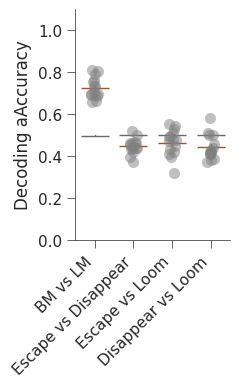


BM vs LM: data_vs_shuffle:
N = 15, 15
data: mean, sem = 0.726, 0.013
bootstrapped: mean, sem = 0.499, 0.001

Normality test (Shapiro-Wilk):
Group data: W = 0.921, p = 0.203
Group bootstrapped: W = 0.932, p = 0.291
all groups are normally distributed → use parametric test.

T-test between data and bootstrapped: t = 17.705, p = 4.8315708171e-17

Escape vs Disappear: data_vs_shuffle:
N = 15, 15
data: mean, sem = 0.448, 0.009
bootstrapped: mean, sem = 0.502, 0.001

Normality test (Shapiro-Wilk):
Group data: W = 0.957, p = 0.644
Group bootstrapped: W = 0.806, p = 0.004
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U between data and bootstrapped: U = 25.000, p = 9.9987015450e-01

Escape vs Loom: data_vs_shuffle:
N = 15, 15
data: mean, sem = 0.466, 0.016
bootstrapped: mean, sem = 0.500, 0.001

Normality test (Shapiro-Wilk):
Group data: W = 0.959, p = 0.676
Group bootstrapped: W = 0.948, p = 0.494
all groups are normally distributed → use parametric test.

T

In [23]:
subpanel = '5h'

decoders = ['svm_BM_LM', 'svm_BM_escp_disp', 'svm_BM_escp_loom', 'svm_BM_disp_loom']
d_names = ['BM vs LM', 'Escape vs Disappear', 'Escape vs Loom', 'Disappear vs Loom']

Real = {key: [] for key in d_names}; Bootstrapped = {key: [] for key in d_names}

for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  [t1, t2, t3, t4, t5] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  if np.sum([t>=8 for t in [t1,t2,t3,t4,t5]])!=5: continue

  for decoder_name, decoder in zip(d_names, decoders):
    with open(output_path+'Decoders/'+decoder+'.pkl','rb') as f: data = pickle.load(f)

    # n_neurons, n_components, n_trials = data['n_neurons'], data['n_components'], data['n_trials']
    real_inst, perm_inst = data['real_inst'], data['perm_inst']

    # get the mean of accuracy score during 2-s before escape
    start, end = [sec*resample_Hz for sec in [8, 10]]

    Real[decoder_name].append(np.mean(real_inst[start:end]))
    Bootstrapped[decoder_name].append(np.mean(perm_inst[:, start:end]))

# STATS
group_values = d_names
summary_data = Real
summary_data2 = Bootstrapped

# print('Each point is all training from a fish')
plt.figure(figsize=[2,3])
sns.stripplot(data=summary_data,color='gray',alpha=0.5,size=8,label='data')
sns.pointplot(data=summary_data,color='sienna',linestyle="none",marker="_",errorbar='se',markersize=20,markeredgewidth=1,errwidth=1)

sns.pointplot(data=summary_data2,color='dimgrey',linestyle="none",marker="_",errorbar='se',markersize=20,markeredgewidth=1,errwidth=1,label='bootstrapped')

plt.ylabel('Decoding aAccuracy'); plt.ylim(0,1.1);
plt.xticks(np.arange(len(d_names)),d_names,rotation=45,ha='right');
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for key, values in summary_data.items():
  col_name = f"{key}_data"
  series_dict[col_name] = pd.Series(values)
for key, values in summary_data2.items():
  col_name = f"{key}_bootstrapped"
  series_dict[col_name] = pd.Series(values)
df = pd.DataFrame(series_dict)
df.to_csv(csv_path+subpanel+".csv", index=False)

for decoder_name in d_names:
  print(f"\n{decoder_name}: data_vs_shuffle:")
  print(f"N = {len(summary_data[decoder_name])}, {len(summary_data2[decoder_name])}")
  print(f"data: mean, sem = {np.mean(summary_data[decoder_name]):.3f}, {stats.sem(summary_data[decoder_name]):.3f}")
  print(f"bootstrapped: mean, sem = {np.mean(summary_data2[decoder_name]):.3f}, {stats.sem(summary_data2[decoder_name]):.3f}")

  compare = ['data', 'bootstrapped'];
  summary = [summary_data[decoder_name], summary_data2[decoder_name]]

  # -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(compare, summary):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = 2; annotation_dict = {}
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary[0], summary[1], alternative='greater')
    print(f"\nT-test between {compare[0]} and {compare[1]}: t = {stat:.3f}, p = {p:.10e}")
  else:
    stat, p = stats.mannwhitneyu(summary[0], summary[1], alternative='greater')
    print(f"\nMann-Whitney U between {compare[0]} and {compare[1]}: U = {stat:.3f}, p = {p:.10e}")
  annotation_dict[(compare[0], compare[1])] = p

## 5i - after

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/5i


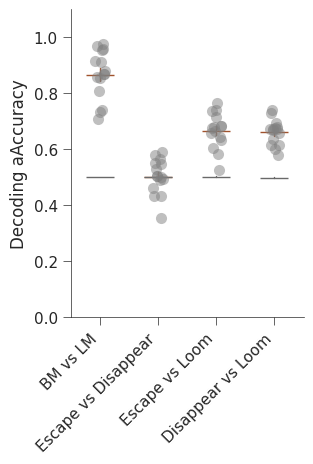

,BM vs LM_data,Escape vs Disappear_data,Escape vs Loom_data,Disappear vs Loom_data,BM vs LM_bootstrapped,Escape vs Disappear_bootstrapped,Escape vs Loom_bootstrapped,Disappear vs Loom_bootstrapped
0,0.807813,0.503125,0.765625,0.675000,0.499500,0.500125,0.494250,0.500125
1,0.878125,0.493750,0.675000,0.693750,0.498437,0.495000,0.501125,0.498750
2,0.956250,0.500000,0.740625,0.659375,0.494688,0.505250,0.506750,0.497625
3,0.957812,0.434375,0.684375,0.671875,0.505000,0.497625,0.499250,0.493750
4,0.732812,0.506250,0.603125,0.728125,0.502750,0.500250,0.510625,0.501750
5,0.968750,0.550000,0.681250,0.637500,0.504313,0.500875,0.500250,0.492250
6,0.975000,0.490625,0.643750,0.681250,0.504625,0.494875,0.502500,0.502250
7,0.707812,0.578125,0.634375,0.671875,0.499625,0.498000,0.503875,0.493125
8,0.739062,0.590625,0.659375,0.615625,0.499688,0.506250,0.488250,0.496875
9,0.868750,0.434375,0.665625,0.671875,0.498125,0.499875,0.503625,0.505625



BM vs LM: data_vs_shuffle:
N = 15, 15
data: mean, sem = 0.867, 0.022
bootstrapped: mean, sem = 0.501, 0.001

Normality test (Shapiro-Wilk):
Group data: W = 0.914, p = 0.154
Group bootstrapped: W = 0.911, p = 0.141
all groups are normally distributed → use parametric test.

T-test between data and bootstrapped: t = 16.274, p = 4.1778268892e-16

Escape vs Disappear: data_vs_shuffle:
N = 15, 15
data: mean, sem = 0.503, 0.016
bootstrapped: mean, sem = 0.500, 0.001

Normality test (Shapiro-Wilk):
Group data: W = 0.948, p = 0.487
Group bootstrapped: W = 0.932, p = 0.290
all groups are normally distributed → use parametric test.

T-test between data and bootstrapped: t = 0.140, p = 4.4470365306e-01

Escape vs Loom: data_vs_shuffle:
N = 15, 15
data: mean, sem = 0.667, 0.016
bootstrapped: mean, sem = 0.502, 0.001

Normality test (Shapiro-Wilk):
Group data: W = 0.966, p = 0.789
Group bootstrapped: W = 0.939, p = 0.375
all groups are normally distributed → use parametric test.

T-test between da

In [24]:
subpanel = '5i'

decoders = ['svm_BM_LM', 'svm_BM_escp_disp', 'svm_BM_escp_loom', 'svm_BM_disp_loom']
d_names = ['BM vs LM', 'Escape vs Disappear', 'Escape vs Loom', 'Disappear vs Loom']

Real = {key: [] for key in d_names}; Bootstrapped = {key: [] for key in d_names}

for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  [t1, t2, t3, t4, t5] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  if np.sum([t>=8 for t in [t1,t2,t3,t4,t5]])!=5: continue

  for decoder_name, decoder in zip(d_names, decoders):
    with open(output_path+'Decoders/'+decoder+'.pkl','rb') as f: data = pickle.load(f)

    # n_neurons, n_components, n_trials = data['n_neurons'], data['n_components'], data['n_trials']
    real_inst, perm_inst = data['real_inst'], data['perm_inst']

    # get the mean of accuracy score during 2-s after escape
    start, end = [sec*resample_Hz for sec in [10, 12]]

    Real[decoder_name].append(np.mean(real_inst[start:end]))
    Bootstrapped[decoder_name].append(np.mean(perm_inst[:, start:end]))

# STATS
group_values = d_names
summary_data = Real
summary_data2 = Bootstrapped

# print('Each point is all training from a fish')
plt.figure(figsize=[3,4])
sns.stripplot(data=summary_data,color='gray',alpha=0.5,size=8,label='data')
sns.pointplot(data=summary_data,color='sienna',linestyle="none",marker="_",errorbar='se',markersize=20,markeredgewidth=1,errwidth=1)

# sns.stripplot(data=summary_data2,color='grey',alpha=0.5,size=8)
sns.pointplot(data=summary_data2,color='dimgrey',linestyle="none",marker="_",errorbar='se',markersize=20,markeredgewidth=1,errwidth=1,label='bootstrapped')

plt.ylabel('Decoding aAccuracy'); plt.ylim(0,1.1);
plt.xticks(np.arange(len(d_names)),d_names,rotation=45,ha='right');
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for key, values in summary_data.items():
  col_name = f"{key}_data"
  series_dict[col_name] = pd.Series(values)
for key, values in summary_data2.items():
  col_name = f"{key}_bootstrapped"
  series_dict[col_name] = pd.Series(values)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+".csv", index=False)

for decoder_name in d_names:
  print(f"\n{decoder_name}: data_vs_shuffle:")
  print(f"N = {len(summary_data[decoder_name])}, {len(summary_data2[decoder_name])}")
  print(f"data: mean, sem = {np.mean(summary_data[decoder_name]):.3f}, {stats.sem(summary_data[decoder_name]):.3f}")
  print(f"bootstrapped: mean, sem = {np.mean(summary_data2[decoder_name]):.3f}, {stats.sem(summary_data2[decoder_name]):.3f}")

  compare = ['data', 'bootstrapped'];
  summary = [summary_data[decoder_name], summary_data2[decoder_name]]

  # -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(compare, summary):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = 2; annotation_dict = {}
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary[0], summary[1], alternative='greater')
    print(f"\nT-test between {compare[0]} and {compare[1]}: t = {stat:.3f}, p = {p:.10e}")
  else:
    stat, p = stats.mannwhitneyu(summary[0], summary[1], alternative='greater')
    print(f"\nMann-Whitney U between {compare[0]} and {compare[1]}: U = {stat:.3f}, p = {p:.10e}")
  annotation_dict[(compare[0], compare[1])] = p

# 5j - ΔZ (BM_disp - LM_disp)

In [14]:
# giant_list to collect all resp across sessions
# stim_names = ['BM_escp','BM_disp','LM_escp','LM_disp','BM_loom']
stim_names = ['BM-escp','BM-disp','Linear-escp','Linear-disp','BM-loom']
giant_list = {
    **{f'psth_{i+1}': [] for i, _ in enumerate(stim_names)},
    **{f'resp_{i+1}': [] for i, _ in enumerate(stim_names)}}

for exp, ffile, z in zip(experiments[:], fcn_files[:], planeNum[:]):
  # print("subject #", exp, ':', ffile)
  zsteps = int(z)
  home_path = data_path + exp + '/' + ffile + '/'
  output_path = save_path + exp + '/' + ffile + '/'

  # load processed 2p
  data = np.load(home_path+'neuron_details.npz', allow_pickle=True)
  traces, traces_Z, xs, ys, zs = data['traces'], data['traces_Z'], data['xs'], data['ys'], data['zs']

  # load psths
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) #
  # load cell selection
  data = np.load(output_path+'ttest_5-8_cells.npz', allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']

  # compile responses of all cells
  big_list = {f'psth_{i+1}': [] for i, n in enumerate(stim_names)}
  for cell in cell_id:
    for i, stim in enumerate(stim_names):
      # append the average psth to master list
      tmp = np.mean(np.array(PSTHs[cell][i]),axis=0);
      big_list[f'psth_{i+1}'].append(tmp)
  for key, lst in big_list.items(): big_list[key] = np.array(lst)

  # append to across fish SUMMARY
  for i, stim in enumerate(stim_names):
    giant_list[f'psth_{i+1}'].extend(big_list[f'psth_{i+1}'])

for key, lst in giant_list.items(): giant_list[key] = np.array(lst)
print('done')

# get metrics for further cell selection
for i, stim in enumerate(stim_names):
  pk = np.argmax(giant_list[f'psth_{i+1}'][:,:],axis=1); giant_list[f'pk_{i+1}'] = np.array(pk)
  t0, t1 = 50, 120 # define window of interest for peak and mean response
  maxF = np.max(giant_list[f'psth_{i+1}'][:,t0:t1],axis=1); giant_list[f'max_{i+1}'] = np.array(maxF)
  meanF = np.mean(giant_list[f'psth_{i+1}'][:,t0:t1],axis=1); giant_list[f'mean_{i+1}'] = np.array(meanF)

# find cells respond to escp/disp action
off_1 = (giant_list['pk_1']>=100)*(giant_list['pk_1']<=120)
off_2 = (giant_list['pk_2']>=100)*(giant_list['pk_2']<=120)
off_3 = (giant_list['pk_3']>=100)*(giant_list['pk_3']<=120)
off_4 = (giant_list['pk_4']>=100)*(giant_list['pk_4']<=120)

# find peak response for each cell
maxF_stim = np.argmax([giant_list['max_1'], giant_list['max_2'], giant_list['max_3'], giant_list['max_4']],axis=0)

done


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/5j


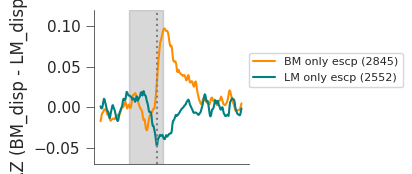

,BM escp cells_0,BM escp cells_1,BM escp cells_2,BM escp cells_3,BM escp cells_4,BM escp cells_5,BM escp cells_6,BM escp cells_7,BM escp cells_8,BM escp cells_9,...,LM escp cells_2542,LM escp cells_2543,LM escp cells_2544,LM escp cells_2545,LM escp cells_2546,LM escp cells_2547,LM escp cells_2548,LM escp cells_2549,LM escp cells_2550,LM escp cells_2551
0,-1.198293,1.247208,0.691103,0.457301,0.083145,0.867038,-0.348540,-0.680366,0.270213,-0.662878,...,0.173580,0.143635,-0.118438,0.194474,-0.530169,-0.469686,0.166663,0.299866,-0.543640,-0.258764
1,-0.918889,1.376979,0.935587,0.547756,0.168747,1.013318,-0.344292,-0.502325,0.256341,-0.675734,...,0.038206,0.128293,0.020251,0.158058,-0.495211,-0.503296,0.116456,0.314776,-0.477487,-0.261699
2,-0.699908,1.386050,1.064538,0.506016,0.177834,1.098723,-0.278014,-0.357767,0.303693,-0.604175,...,-0.201757,0.144278,0.137331,0.159208,-0.407898,-0.583624,0.112991,0.394249,-0.207584,-0.149235
3,-0.380239,1.337350,1.059522,0.479232,0.288333,1.149471,-0.108244,-0.238630,0.283068,-0.516991,...,-0.354365,0.160239,0.170290,0.234320,-0.362843,-0.564487,0.085420,0.290873,-0.046792,0.025008
4,0.055944,1.222082,1.166984,0.493876,0.447507,1.175919,0.145554,-0.155964,0.175648,-0.499536,...,-0.400617,0.168425,0.108645,0.349319,-0.364184,-0.408731,-0.002179,0.098594,-0.020316,0.225693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1.062022,-0.257111,0.413874,-0.308856,-2.265350,0.246219,0.617821,0.147262,0.554161,0.741717,...,-0.039025,0.553886,0.617066,-0.058275,0.152701,0.195049,-0.001510,-0.197937,-0.148394,0.542898
246,0.945690,-0.400863,0.564847,-0.105351,-2.116912,0.289848,0.756866,-0.065981,0.714745,0.717936,...,-0.146344,0.534899,0.546466,-0.111891,0.115095,0.205446,-0.053484,-0.116862,-0.149055,0.565995
247,0.948307,-0.401207,0.775474,-0.105228,-2.006534,0.371858,0.964480,-0.200080,0.782066,0.762767,...,-0.184283,0.527811,0.446851,-0.112593,0.145061,0.183028,0.015790,-0.084917,-0.092571,0.495076
248,0.968032,-0.319797,0.850855,-0.062244,-1.907902,0.562308,1.028325,-0.031096,0.800887,0.779172,...,-0.140000,0.523150,0.448924,-0.140749,0.196849,0.241258,0.219930,-0.163006,-0.064073,0.375081


In [16]:
subpanel = '5j'
plt.figure(figsize=[2,2]); series_dict = {}

mask = off_1*~off_3
delta = giant_list['psth_2']-giant_list['psth_4']
plt.plot(np.mean(delta[mask,:],axis=0),color='darkorange',label=f'BM only escp ({np.sum(mask)})')
plt.fill_between(np.mean(delta[mask,:],axis=0),np.mean(delta[mask,:],axis=0)-stats.sem(delta[mask,:],axis=0),\
                 np.mean(delta[mask,:],axis=0)+stats.sem(delta[mask,:],axis=0),alpha=0.3,color='darkorange',lw=0)
for c, psth in enumerate(delta[mask,:]):
  series_dict[f'BM escp cells_{c}'] = pd.Series(psth)

mask = off_3*~off_1
delta = giant_list['psth_2']-giant_list['psth_4']
plt.plot(np.mean(delta[mask,:],axis=0),color='teal', label=f'LM only escp ({np.sum(mask)})')
plt.fill_between(np.mean(delta[mask,:],axis=0),np.mean(delta[mask,:],axis=0)-stats.sem(delta[mask,:],axis=0),\
                 np.mean(delta[mask,:],axis=0)+stats.sem(delta[mask,:],axis=0),alpha=0.3,color='teal',lw=0)
for c, psth in enumerate(delta[mask,:]):
  series_dict[f'LM escp cells_{c}'] = pd.Series(psth)

plt.xticks([]); plt.axvspan(50,110,color='gray',alpha=0.3);
plt.axvline(100,color='gray',ls=':'); plt.ylim(-0.07, 0.12)
plt.ylabel('ΔZ (BM_disp - LM_disp)')

plt.legend(loc=[1,0.5],fontsize=8)
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+".csv", index=False)

# Data: BG vs linear VR escape

In [25]:
gsheet = 'https://docs.google.com/spreadsheets/d/1bSfcczIO4V62vPDB93Xjm2VDwlayalswnmi6PDiiLps/edit?gid=0#gid=0'
tab_name = 'BG_linear_escape'

experiment_class = f'Social escape - {tab_name}'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class

data_path = path + '/Data/'
save_path = path + '/Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

,experiment,time_stamps,tank,metadata,fish_num,sex,exp_type,fps_Hz,rig_mm,vid_px,body_length,experiment_date,condition
0,vid_1.mp4.000_vid_1.analysis.h5,vid_1.csv,T61,vid_1_metadata.csv,1,f,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear
1,vid_8.mp4.000_vid_8.analysis.h5,vid_8.csv,T61,vid_8_metadata.csv,1,f,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear
2,vid_6.mp4.000_vid_6.analysis.h5,vid_6.csv,T61,vid_6_metadata.csv,1,m,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear
3,vid_4.mp4.000_vid_4.analysis.h5,vid_4.csv,T61,vid_4_metadata.csv,1,m,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear
4,vid_3.mp4.000_vid_3.analysis.h5,vid_3.csv,T61,vid_3_metadata.csv,1,m,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear
...,...,...,...,...,...,...,...,...,...,...,...,...,...
264,vid_14.mp4.000_vid_14.analysis.h5,vid_14.csv,U2,vid_14_metadata.csv,1,,DC_negative_CL_alternating.py,50,265,800,12,40726B,BG_negative
265,vid_13.mp4.000_vid_13.analysis.h5,vid_13.csv,U2,vid_13_metadata.csv,1,,DC_negative_CL_alternating.py,50,265,800,12,40726B,BG_negative
266,vid_12.mp4.000_vid_12.analysis.h5,vid_12.csv,U2,vid_12_metadata.csv,1,,DC_negative_CL_alternating.py,50,265,800,12,40726B,BG_negative
267,vid_11.mp4.000_vid_11.analysis.h5,vid_11.csv,U2,vid_11_metadata.csv,1,,DC_negative_CL_alternating.py,50,265,800,12,40726B,BG_negative


In [26]:
analysis_path = save_path

exps=metadata.index
#Create save directory for analysis
exp_dates = metadata['experiment_date'].tolist()
save_paths = [f'{analysis_path}{exp_date}/{exp}/lev0_basics.npz' for exp_date, exp in zip(exp_dates, exps)]
metadata['save_path'] = save_paths

#Add raw data path
data_paths = [f'{data_path}{exp_date}/{exp}/' for exp_date,exp in zip(exp_dates,exps)]
metadata['raw_data_path'] = data_paths

#Add timestamp path
TimeStamps=metadata['time_stamps'].tolist()
time_stamp_paths = [f'{data_path}/{exp_date}/{time}' for exp_date,time in zip(exp_dates,TimeStamps)]
metadata['time_stamp_path'] = time_stamp_paths

#Add bounding box path
boxes = [item for item in ['bounding_box_four_corners.csv'] for _ in range(len(metadata))]
box_dim_path=[f'{data_path}{exp_date}/{bbox}' for exp_date,bbox in zip(exp_dates,boxes)]
metadata['box_dim_path'] = box_dim_path

#Add metadata path for each video
metadatas = metadata['metadata'].tolist()
metadata_paths = [f'{data_path}{exp_date}/{meta}' for exp_date,meta in zip(exp_dates,metadatas)]
metadata['metadata_path'] = metadata_paths

#display(metadata)
display(metadata)

,time_stamps,tank,metadata,fish_num,sex,exp_type,fps_Hz,rig_mm,vid_px,body_length,experiment_date,condition,save_path,raw_data_path,time_stamp_path,box_dim_path,metadata_path
experiment,,,,,,,,,,,,,,,,,
vid_1.mp4.000_vid_1.analysis.h5,vid_1.csv,T61,vid_1_metadata.csv,1,f,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_8.mp4.000_vid_8.analysis.h5,vid_8.csv,T61,vid_8_metadata.csv,1,f,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_6.mp4.000_vid_6.analysis.h5,vid_6.csv,T61,vid_6_metadata.csv,1,m,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_4.mp4.000_vid_4.analysis.h5,vid_4.csv,T61,vid_4_metadata.csv,1,m,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_3.mp4.000_vid_3.analysis.h5,vid_3.csv,T61,vid_3_metadata.csv,1,m,DC_disappear_CL_alternating_linear_revision.py,50,265,800,12,21026,linear_disappear,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vid_14.mp4.000_vid_14.analysis.h5,vid_14.csv,U2,vid_14_metadata.csv,1,,DC_negative_CL_alternating.py,50,265,800,12,40726B,BG_negative,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_13.mp4.000_vid_13.analysis.h5,vid_13.csv,U2,vid_13_metadata.csv,1,,DC_negative_CL_alternating.py,50,265,800,12,40726B,BG_negative,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_12.mp4.000_vid_12.analysis.h5,vid_12.csv,U2,vid_12_metadata.csv,1,,DC_negative_CL_alternating.py,50,265,800,12,40726B,BG_negative,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...


## helper fcn

In [27]:
def get_escape_data_alternating(EllapsedTime,fish_showing,fish_escaping,trial_order):
      #Pad fish_showing
    fish_showing = np.pad(fish_showing,pad_width=1, mode='constant',constant_values=0)
    fish_escaping = np.pad(fish_escaping,pad_width=1, mode='constant',constant_values=0)

    #Find transitions in showing fish (i.e. start and stop indexes)
    fs_idx=np.clip(np.where(np.diff(fish_showing.astype(int))==1)[0],0,len(EllapsedTime)-1)
    fse_idx=np.clip(np.where(np.diff(fish_showing.astype(int))==-1)[0],0,len(EllapsedTime)-1)

    ##Fish show output
    start_fs=[]
    end_fs=[]
    for x in range(0,len(fs_idx)):
      start_fs.append(EllapsedTime[fs_idx[x]])
    for x in range(0,len(fse_idx)):
      end_fs.append(EllapsedTime[fse_idx[x]])

    fs_results=[]
    for start,stop in zip(start_fs,end_fs):
      fs_results.append({"StartFishShowing":start,"EndFishShowing":stop})
    fs_df=pd.DataFrame(fs_results)


    #Find transitions in fish escaping
    fe_idx=np.clip(np.where(np.diff(fish_escaping.astype(int))==1)[0],0,len(EllapsedTime)-1)
    fse_idx=np.clip(np.where(np.diff(fish_escaping.astype(int))==-1)[0],0,len(EllapsedTime)-1)

    ###Fish escape output
    start_fe=[]
    end_fe=[]
    for x in range(0,len(fe_idx)):
      start_fe.append(EllapsedTime[fe_idx[x]-1])
    for x in range(0,len(fse_idx)):
      end_fe.append(EllapsedTime[fse_idx[x]-1])

    fe_results=[]
    for start,stop,trial in zip(start_fe,end_fe,trial_order):
      fe_results.append({"StartFishEscaping":start,"EndFishShowing":stop,"NumFishEscape":trial})
    fe_df=pd.DataFrame(fe_results)

    return fs_df,fe_df

def get_arena_dims(data):
  ArenaDims=pd.DataFrame(data['ArenaDims'].item())
  ArenaDims['Points'] = ArenaDims['Points'].apply(ast.literal_eval)

  #Calculate width based on selected points
  TopXY_L=np.array([ArenaDims['Points'].iloc[0][0][0],ArenaDims['Points'].iloc[0][0][1]])
  TopXY_R=np.array([ArenaDims['Points'].iloc[0][1][0],ArenaDims['Points'].iloc[0][1][1]])
  ArenaWidth=np.sqrt(np.sum(((TopXY_L-TopXY_R)**2))).astype(int)

  #Calculate height based on selected points
  TopXY_R=np.array([ArenaDims['Points'].iloc[0][1][0],ArenaDims['Points'].iloc[0][1][1]])
  BottomXY_R=np.array([ArenaDims['Points'].iloc[0][2][0],ArenaDims['Points'].iloc[0][2][1]])
  ArenaHeight=np.sqrt(np.sum(((TopXY_R-BottomXY_R)**2))).astype(int)


  #Store values in array
  ArenaDims['BBW']=ArenaWidth
  ArenaDims['BBH']=ArenaHeight
  return ArenaDims

In [28]:
SE_colors = {'BG_negative':'#b7b7b7', 'BG_escape':'#df5106','BG_disappear':'#8A3324','BG_loom':'#d42222',
                'linear_negative':'#98b5ad','linear_escape':'#02b0b0','linear_disappear':'#036661'}

# 5k - VR setup + screenshots of escp vs disp

# 5l - dist to VR time series (BM)

Skipping fish 29 in BG_negative
39 fish included for BG_negative
39 fish included for BG_escape
41 fish included for BG_disappear
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/5l


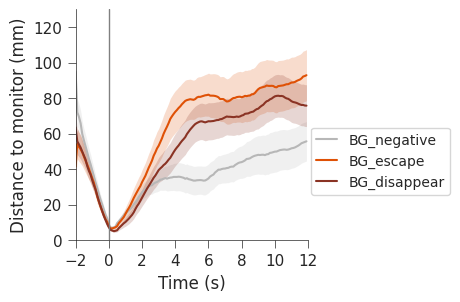

,BG_negative_1,BG_negative_2,BG_negative_3,BG_negative_4,BG_negative_5,BG_negative_6,BG_negative_7,BG_negative_8,BG_negative_9,BG_negative_10,...,BG_disappear_32,BG_disappear_33,BG_disappear_34,BG_disappear_35,BG_disappear_36,BG_disappear_37,BG_disappear_38,BG_disappear_39,BG_disappear_40,BG_disappear_41
0,143.252232,NaN,NaN,49.562491,NaN,66.087965,55.276186,NaN,NaN,NaN,...,NaN,42.581899,NaN,69.706204,NaN,NaN,160.068462,NaN,NaN,NaN
1,136.062307,17.416302,42.932293,46.835951,90.584217,56.418337,50.504273,140.695946,3.815591,92.076169,...,89.733197,36.648261,96.031900,68.553273,189.292904,NaN,156.816566,1.475063,108.394643,NaN
2,130.558372,15.348100,44.975675,44.939978,87.618555,47.824412,45.228485,131.222057,3.887058,89.522184,...,84.961008,32.712109,92.488122,67.778052,181.888917,NaN,144.947574,2.972339,105.244762,NaN
3,122.555053,14.967263,46.789479,39.488525,84.575032,42.184628,37.930055,126.519208,2.696684,78.145876,...,82.754571,29.308981,90.718442,65.936205,172.293002,NaN,135.994886,2.741793,99.771046,NaN
4,116.825453,13.311806,48.482396,35.955438,76.096773,39.561409,33.855766,120.893999,2.644081,66.000025,...,78.853951,26.831408,88.786110,62.797999,160.648040,NaN,132.187612,2.927373,92.965219,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,87.499201,98.941081,3.783989,7.660550,224.736559,11.486488,4.864550,36.066962,141.236474,19.316005,...,76.279364,39.276577,159.029325,5.261862,2.178091,101.775051,63.566290,5.724057,3.595049,3.342602
136,93.545679,100.798396,3.514225,7.913205,224.379313,16.233914,6.339862,37.979744,135.572288,18.201822,...,73.720974,39.342847,156.323922,5.661374,3.850346,97.053989,71.737661,4.305514,3.782808,4.116527
137,104.332783,102.318761,3.303151,7.787337,222.899212,21.937831,6.602543,41.800979,126.638513,16.679420,...,70.987876,41.197657,153.556619,5.289487,5.581206,90.857959,76.338320,4.278634,3.824192,2.489850
138,111.607069,100.065601,3.365863,7.778205,220.638873,26.654421,6.740096,45.306107,121.338549,16.514622,...,70.607611,41.227922,151.882632,5.174267,7.331122,87.497081,79.210089,4.278092,3.357260,3.357678


In [ ]:
import ast

subpanel = '5l'

# Plot disengagement
TimeBufferAfter = 12
TimeBufferBefore = 2
distances = []
Times = []
escape_data=[]
metadata_subset = metadata
stim_types = ['BG_negative','BG_escape','BG_disappear']

# initiate df to save source data into csv
series_dict = {}

# Remove negative control stim types
fig = plt.figure(figsize=(3, 3))
for stim in stim_types:
  metadata_subset = metadata[metadata['condition'] == stim].reset_index()
  counter = 0
  data_paths = []
  for i in range(len(metadata_subset.index)):
      data_path = metadata_subset['save_path'].iloc[i]
      data = np.load(data_path, allow_pickle=True)
      fish_num, bodylength = data['fish_num'], data['f_bodylength_mm']
      exp_type, f_x, f_y = data['exp_type'], data['f_x'], data['f_y']
      EllapsedTime = data['time_stamps']
      condition = data['condition']
      ArenaDims = get_arena_dims(data)
      trial_order = ast.literal_eval(data['vid_metadata'].item()['trial order'])
      EngageThresh=float(data['vid_metadata'].item()['Engagement distance threshold'])
      # Get distance to left wall
      TopLeftX, TopLeftY = ArenaDims['Points'].values[0][0]
      BottomLeftX, BottomLeftY = ArenaDims['Points'].values[0][3]
      m = (TopLeftY - BottomLeftY) / (TopLeftX - BottomLeftX)
      b = TopLeftY - (m * TopLeftX)


      # Calculate scale
      arenaHeightPix=np.sqrt( (TopLeftX-BottomLeftX )**2 + (TopLeftY-BottomLeftY)**2)
      scale=metadata['rig_mm'].iloc[i]/ArenaDims['BBW'].values[0]
      dist2line = np.abs(m * f_x - f_y + b) / np.sqrt(m**2 + 1)

      # Get stim status and escape time stamps
      fish_escaping = data['fish_escaping']

      fish_showing = data['fish_showing']
      fs,fe=get_escape_data_alternating(EllapsedTime,fish_showing,fish_escaping,trial_order)
      for escape_event in range(len(fe)):
          start_time = fe['StartFishEscaping'].iloc[escape_event] - TimeBufferBefore
          end_time = fe['StartFishEscaping'].iloc[escape_event] + TimeBufferAfter
          start_idx = np.nanargmin(np.abs(EllapsedTime-start_time))
          end_idx = np.nanargmin(np.abs(EllapsedTime-end_time))
          trigger_idx = np.nanargmin(np.abs(EllapsedTime-fe['StartFishEscaping'].iloc[escape_event]))
          if sum(fish_escaping) < 10 or trigger_idx>=end_idx:
            print(f'Skipping fish {i} in {condition}')
            continue
          data_paths.append(data_path)
          counter +=1


          escape_data.append({
              "NumEscapees": fe["NumFishEscape"].iloc[escape_event],
              "Times": EllapsedTime[start_idx:end_idx] - EllapsedTime[trigger_idx],
              "Distances": dist2line[0][start_idx:end_idx] * scale,
              "fish":i,
              "Condition":stim})
  print(f'{counter} fish included for {stim}')

# Plot average
histbin = 0.1
TotalTime = TimeBufferAfter+TimeBufferBefore
TimeBins = np.linspace(-TimeBufferBefore, TimeBufferAfter-histbin, int(TotalTime / histbin))
num_escapees = [5]
binned_data = []
for stim in stim_types:
    plot_color = SE_colors[stim]
    escape_events = [event for event in escape_data if event["Condition"] == stim]
    Times = [event["Times"] for event in escape_events]
    distances = [event["Distances"] for event in escape_events]
    conditions = [event["Condition"] for event in escape_events]

    # Get time bin indices
    bin_indices = [np.digitize(time_series, TimeBins) - 1 for time_series in Times]

    # Create distance array
    DistanceArray = np.full((len(TimeBins), len(distances)), np.nan)

    # save
    for j in range(DistanceArray.shape[1]):
      col_name = f'{stim}_{j+1}'
      series_dict[col_name] = pd.Series(DistanceArray[:,j])

    for fish_idx in range(len(distances)):
        t = Times[fish_idx]
        d = distances[fish_idx]
        if len(t) > 1:
            # Create an interpolation function for this specific fish
            f = interp1d(t, d, bounds_error=False, fill_value=np.nan)
            DistanceArray[:, fish_idx] = f(TimeBins)

    DistanceMean=np.nanmean(DistanceArray,axis=1)
    DistanceSEM=(np.nanstd(DistanceArray,axis=1)/np.sqrt(len(distances)))
    plt.plot(TimeBins, DistanceMean,label=stim,color=plot_color)
    plt.fill_between(TimeBins, (DistanceMean- DistanceSEM), (DistanceMean+ DistanceSEM), alpha=0.2,color=plot_color,lw=0)
    # Append to binned data for subsequent plotting #
    binned_data.append({'Time': TimeBins,
                        'Distance': DistanceArray,
                        'Condition': [stim] * len(DistanceArray),
                        'Data_paths': np.array(data_paths)})


plt.ylabel('Distance to monitor (mm)')
plt.xlabel('Time (s)'); plt.xlim(-TimeBufferBefore,TimeBufferAfter); plt.xticks(np.arange(-TimeBufferBefore,TimeBufferAfter+1,2))
plt.axvline(0,c='grey',lw=1);
plt.legend(bbox_to_anchor=(1,.5),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
sns.despine()

ax = plt.gca()  # Get current axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylim(0,130); # plt.xlim(-5,15)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# 5m - dist to VR stats (BM)

In [ ]:
# This plot finds the distance the fish traveled from the wall at 10s after the stim and makes a fun dot plot.
from scipy import stats
try:
  import pingouin as pg
except:
  !pip install pingouin
  import pingouin as pg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.1 MB/s eta 0:00:00


Skipping fish 29 in BG_negative
39 fish included for BG_negative
39 fish included for BG_escape
41 fish included for BG_disappear
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/5m


/tmp/ipykernel_22792/213058097.py:152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


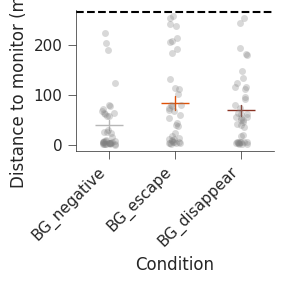

Ns, means, and  sems for data:
BG_negative: (N=39) 40.399, 9.173
BG_escape: (N=39) 84.081, 13.536
BG_disappear: (N=41) 69.827, 10.603
--- Omnibus Test Results ---
Kruskal-Wallis H-statistic: 9.2222
p-value: 0.0099

Significant difference found! Running Dunn's post-hoc test...

--- Dunn's Post-Hoc p-values Matrix ---
              BG_negative  BG_escape  BG_disappear
BG_negative      1.000000   0.013155      0.037663
BG_escape        0.013155   1.000000      0.592246
BG_disappear     0.037663   0.592246      1.000000


,BG_negative,BG_escape,BG_disappear
0,26.288537,4.749623,6.708196
1,68.299007,3.718971,73.498625
2,62.147248,6.194910,3.024592
3,7.642382,8.707926,79.850461
4,223.639263,256.719549,7.414177
5,16.584512,241.791338,7.332879
6,4.390491,253.460896,46.636713
7,24.860855,6.713859,61.281445
8,123.873585,205.015118,253.142779
9,6.643506,213.148739,243.138312


In [ ]:
import ast
subpanel = '5m'

TimeBufferAfter = 12
TimeBufferBefore = 0
SE_colors = {'BG_negative':'#b7b7b7',
                'BG_escape':'#df5106',
                'BG_disappear':'#8A3324',
                'BG_loom':'#d42222',
                'linear_negative':'#98b5ad',
                'linear_escape':'#02b0b0',
                'linear_disappear':'#036661'}

stim_types = ['BG_negative','BG_escape','BG_disappear']

escape_data = []
for stim in stim_types:
  metadata_subset = metadata[metadata['condition'] == stim].reset_index()
  counter = 0
  data_paths = []
  for i in range(len(metadata_subset.index)):
      data_path = metadata_subset['save_path'].iloc[i]
      data = np.load(data_path, allow_pickle=True)
      fish_num, bodylength = data['fish_num'], data['f_bodylength_mm']
      exp_type, f_x, f_y = data['exp_type'], data['f_x'], data['f_y']
      EllapsedTime = data['time_stamps']
      condition = data['condition']
      ArenaDims = get_arena_dims(data)
      trial_order = ast.literal_eval(data['vid_metadata'].item()['trial order'])
      EngageThresh=float(data['vid_metadata'].item()['Engagement distance threshold'])

      # Get distance to left wall
      TopLeftX, TopLeftY = ArenaDims['Points'].values[0][0]
      BottomLeftX, BottomLeftY = ArenaDims['Points'].values[0][3]
      m = (TopLeftY - BottomLeftY) / (TopLeftX - BottomLeftX)
      b = TopLeftY - (m * TopLeftX)


      # Calculate scale
      arenaHeightPix=np.sqrt( (TopLeftX-BottomLeftX )**2 + (TopLeftY-BottomLeftY)**2)
      scale=metadata['rig_mm'].iloc[i]/ArenaDims['BBW'].values[0]
      dist2line = np.abs(m * f_x - f_y + b) / np.sqrt(m**2 + 1)
      # Get stim status and escape time stamps
      fish_escaping = data['fish_escaping']
      fish_showing = data['fish_showing']
      fs,fe=get_escape_data_alternating(EllapsedTime,fish_showing,fish_escaping,trial_order)


      data_paths.append(data_path)
      for escape_event in range(len(fe)):
          start_time = fe['StartFishEscaping'].iloc[escape_event] - TimeBufferBefore
          end_time = fe['StartFishEscaping'].iloc[escape_event] + TimeBufferAfter
          start_idx = np.nanargmin(np.abs(EllapsedTime-start_time))#, side="left")
          end_idx = np.nanargmin(np.abs(EllapsedTime-end_time))#, side="right")
          # Calculate velocity
          f_x_filt = np.array(f_x[0,start_idx:end_idx])
          f_y_filt = np.array(f_y[0,start_idx:end_idx])
          EllapsedTime_filt = np.array(EllapsedTime[start_idx:end_idx])
          if end_idx<=start_idx or sum(fish_escaping) < 10:
            print(f'Skipping fish {i} in {condition}')
            continue
          counter +=1

          dt = np.diff(EllapsedTime_filt)
          # Put nan in front of dt array to size match
          dt = np.insert(dt, 0, np.nan)
          dt[dt==0] = np.nan
          dx = np.diff(f_x_filt)
          dx = np.insert(dx, 0, np.nan)
          dy = np.diff(f_y_filt)
          dy = np.insert(dy, 0, np.nan)
          velocity = np.sqrt(dx**2 + dy**2) / dt
          # Get distance at trigger
          escape_data.append({
              "NumEscapees": fe["NumFishEscape"].iloc[escape_event],
              "Times": EllapsedTime[start_idx:end_idx] - fe['StartFishEscaping'].iloc[escape_event],
              "Distances": dist2line[0][start_idx:end_idx] * scale,
              "Velocity": velocity,
              "fish":i,
              "Condition":stim
          })

  print(f'{counter} fish included for {stim}')

# Plot average
histbin = 0.1
TotalTime = TimeBufferAfter+TimeBufferBefore
TimeBins = np.linspace(-TimeBufferBefore, TimeBufferAfter-histbin, int(TotalTime / histbin))
num_escapees = [5]
binned_data = []
for stim in stim_types:
    plot_color = SE_colors[stim]
    escape_events = [event for event in escape_data if event["Condition"] == stim]
    Times = [event["Times"] for event in escape_events]
    distances = [event["Distances"] for event in escape_events]
    conditions = [event["Condition"] for event in escape_events]

    # Create distance array
    DistanceArray = np.full((len(TimeBins), len(distances)), np.nan)

    for fish_idx in range(len(distances)):
        t = Times[fish_idx]
        d = distances[fish_idx]

        # Create an interpolation function for this specific fish
        f = interp1d(t, d, bounds_error=False, fill_value=np.nan)
        DistanceArray[:, fish_idx] = f(TimeBins)

    binned_data.append({'Time': TimeBins,
                        'Distance': DistanceArray,
                        'Condition': [stim] * len(DistanceArray),
                        'Data_paths': np.array(data_paths)})


## Create an SEM plot and do stats ##
StartTime = 5
EndTime = 12 #seconds after stimulus onset
bin_df = pd.DataFrame(binned_data)
bin_df = bin_df.explode(['Time', 'Distance',  'Condition'])
bin_df = bin_df.reset_index(drop=True)
plot_df = pd.DataFrame(columns=['Time', 'Distance', 'Condition'])

dfs = []
for stim in stim_types:
    bin_df_subset = bin_df[bin_df['Condition'] == stim]
    idx_start = np.searchsorted(bin_df_subset['Time'], StartTime)
    idx_end = np.searchsorted(bin_df_subset['Time'], EndTime)

    distances = np.stack(bin_df_subset['Distance'].iloc[idx_start:idx_end])
    median_distances = np.nanmedian(np.vstack(distances),axis=0)
    mini_df = pd.DataFrame({
        'Distance': median_distances,
        'Condition': [bin_df_subset['Condition'].iloc[0]] * len(median_distances),
        'Fish_ID': np.arange(0,len(median_distances))
    })
    dfs.append(mini_df)

plot_df = pd.concat(dfs, ignore_index=True)
condition_order = stim_types # Desired order

plt.figure(figsize=(3, 3))
ax = plt.gca()
ax.set_ylabel("Distance to monitor (mm)")

sns.stripplot(data=plot_df, x="Condition", y="Distance", order=condition_order,\
              color='gray',alpha=0.3,size=5)
sns.pointplot(data=plot_df, x="Condition", y="Distance", order=condition_order,\
              palette=SE_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);

ax.axhline(y=265,linestyle='--',color='black')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# Remove top box line and right box line
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

group_arrays = [plot_df[plot_df['Condition'] == cond]['Distance'].values for cond in condition_order]


# stats
print("Ns, means, and  sems for data:")
for cond, data in zip(condition_order,group_arrays):
  print(f'{cond}: (N={len(data)}) {np.nanmean(data):.3f}, {scipy.stats.sem(data):.3f}')

# Run Kruskal-Wallis H-test
h_stat, p_val = stats.kruskal(*group_arrays)
print("--- Omnibus Test Results ---")
print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"p-value: {p_val:.4f}")

# 2. Post-hoc Dunn's test (If Significant)
if p_val < 0.05:
    print("\nSignificant difference found! Running Dunn's post-hoc test...")

    # Run Dunn's test with Holm-Bonferroni correction
    dunn_matrix = scikit.posthoc_dunn(
        plot_df,
        val_col='Distance',
        group_col='Condition',
        p_adjust='Holm')

    # Filter and reorder the giant matrix to match your list order perfectly
    ordered_dunn = dunn_matrix.loc[condition_order, condition_order]

    print("\n--- Dunn's Post-Hoc p-values Matrix ---")
    # Display the styled matrix or just print it
    print(ordered_dunn)
else:
    print("\nNo significant differences found across conditions.")

# save source data into csv
series_dict = {}
for key, values in zip(condition_order,group_arrays):
  series_dict[f'{key}'] = pd.Series(values)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f".csv", index=False)





# 5n - dist to VR time series (LM)

35 fish included for linear_negative
Skipping fish 2 in linear_escape
Skipping fish 4 in linear_escape
36 fish included for linear_escape
34 fish included for linear_disappear
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/5n


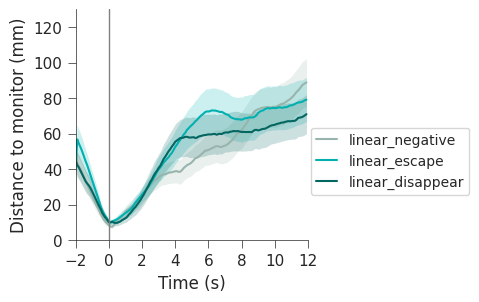

,linear_negative_1,linear_negative_2,linear_negative_3,linear_negative_4,linear_negative_5,linear_negative_6,linear_negative_7,linear_negative_8,linear_negative_9,linear_negative_10,...,linear_disappear_25,linear_disappear_26,linear_disappear_27,linear_disappear_28,linear_disappear_29,linear_disappear_30,linear_disappear_31,linear_disappear_32,linear_disappear_33,linear_disappear_34
0,NaN,NaN,80.359250,NaN,NaN,NaN,NaN,43.749478,67.842484,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.800710,73.512339,77.164766,NaN,2.299947,6.392329,4.472752,36.416069,65.330861,NaN,...,62.318219,131.419923,3.673732,10.086972,77.207107,49.256661,11.694116,19.360626,35.028253,4.882198
2,2.796535,67.627159,75.151011,NaN,2.306197,6.622415,4.437821,27.199208,64.195654,NaN,...,62.314504,129.839170,3.553364,10.068636,78.848590,51.081479,11.611263,18.680921,31.140333,4.943535
3,2.721909,65.578304,72.763284,NaN,2.319566,6.523375,4.576285,21.687046,62.648496,NaN,...,62.316742,129.427026,3.642888,10.141474,78.937347,52.713668,10.194966,18.536693,27.649594,5.197742
4,1.947159,61.991951,69.434470,NaN,2.299410,6.980425,4.385601,19.601604,62.578290,NaN,...,62.382484,127.796457,3.791802,10.116373,79.033392,52.777075,11.208949,18.536536,25.889569,4.926637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,27.821749,27.515866,109.410640,61.639393,124.870822,7.275726,4.257816,90.565125,233.636037,67.493007,...,50.411601,49.869410,3.311083,242.689333,75.662410,78.368623,176.753120,19.757705,75.628097,6.414376
136,25.753845,24.247304,111.021505,61.561356,126.532616,7.402489,4.370993,93.779647,235.313840,67.471470,...,48.524157,51.254082,3.347463,242.618072,78.670191,81.837624,178.517731,19.596134,77.675935,6.445771
137,24.171821,23.328575,111.216937,61.323249,128.403703,7.228805,5.740083,94.422547,233.727283,67.482897,...,48.236767,52.674756,3.455454,242.298296,80.417610,82.111382,180.334372,19.378563,77.656524,6.407446
138,19.849404,21.944477,110.969149,59.853810,128.823648,5.565596,4.153761,96.690437,231.265970,67.478727,...,46.660099,53.944205,3.563199,240.749066,84.348210,84.290070,180.571148,19.440461,79.281637,5.153368


In [29]:
import ast
subpanel = '5n'

# Plot disengagement
TimeBufferAfter = 12
TimeBufferBefore = 2
FishEscapeTime = 0
distances = []
Times = []
escape_data=[]
metadata_subset = metadata
stim_types = ['linear_negative','linear_escape','linear_disappear']

# initiate df to save source data into csv
series_dict = {}

fig = plt.figure(figsize=(3, 3))
for stim in stim_types:
  metadata_subset = metadata[metadata['condition'] == stim].reset_index()
  counter = 0
  data_paths = []
  for i in range(len(metadata_subset.index)):
      data_path = metadata_subset['save_path'].iloc[i]
      data = np.load(data_path, allow_pickle=True)
      fish_num, bodylength = data['fish_num'], data['f_bodylength_mm']
      exp_type, f_x, f_y = data['exp_type'], data['f_x'], data['f_y']
      EllapsedTime = data['time_stamps']
      condition = data['condition']
      ArenaDims = get_arena_dims(data)
      trial_order = ast.literal_eval(data['vid_metadata'].item()['trial order'])
      EngageThresh=float(data['vid_metadata'].item()['Engagement distance threshold'])
      #con=data['condition']
      # Get distance to left wall
      TopLeftX, TopLeftY = ArenaDims['Points'].values[0][0]
      BottomLeftX, BottomLeftY = ArenaDims['Points'].values[0][3]
      m = (TopLeftY - BottomLeftY) / (TopLeftX - BottomLeftX)
      b = TopLeftY - (m * TopLeftX)

      # Calculate scale
      arenaHeightPix=np.sqrt( (TopLeftX-BottomLeftX )**2 + (TopLeftY-BottomLeftY)**2)
      scale=metadata['rig_mm'].iloc[i]/ArenaDims['BBW'].values[0]
      dist2line = np.abs(m * f_x - f_y + b) / np.sqrt(m**2 + 1)

      # Get stim status and escape time stamps
      fish_escaping = data['fish_escaping']
      if sum(fish_escaping) < 10:
        print(f'Skipping fish {i} in {condition}')
        continue
      data_paths.append(data_path)
      counter +=1
      fish_showing = data['fish_showing']
      fs,fe=get_escape_data_alternating(EllapsedTime,fish_showing,fish_escaping,trial_order)
      for escape_event in range(len(fe)):
          start_time = fe['StartFishEscaping'].iloc[escape_event] - TimeBufferBefore
          end_time = fe['StartFishEscaping'].iloc[escape_event] + TimeBufferAfter
          start_idx = np.nanargmin(np.abs(EllapsedTime-start_time))
          end_idx = np.nanargmin(np.abs(EllapsedTime-end_time))
          trigger_idx = np.nanargmin(np.abs(EllapsedTime-fe['StartFishEscaping'].iloc[escape_event]))
          escape_data.append({
              "NumEscapees": fe["NumFishEscape"].iloc[escape_event],
              "Times": EllapsedTime[start_idx:end_idx] - EllapsedTime[trigger_idx],
              "Distances": dist2line[0][start_idx:end_idx] * scale,
              "fish":i,
              "Condition":stim
          })
  print(f'{counter} fish included for {stim}')

# Plot average
histbin = 0.1
TotalTime = TimeBufferAfter+TimeBufferBefore
TimeBins = np.linspace(-TimeBufferBefore, TimeBufferAfter-histbin, int(TotalTime / histbin))
num_escapees = [5]
binned_data = []
for stim in stim_types:
    plot_color = SE_colors[stim]
    escape_events = [event for event in escape_data if event["Condition"] == stim]
    Times = [event["Times"] for event in escape_events]
    distances = [event["Distances"] for event in escape_events]
    conditions = [event["Condition"] for event in escape_events]

    # Get time bin indices
    bin_indices = [np.digitize(time_series, TimeBins) - 1 for time_series in Times]

    # Create distance array
    DistanceArray = np.full((len(TimeBins), len(distances)), np.nan)

    # save
    for j in range(DistanceArray.shape[1]):
      col_name = f'{stim}_{j+1}'
      series_dict[col_name] = pd.Series(DistanceArray[:,j])

    for fish_idx in range(len(distances)):
        t = Times[fish_idx]
        d = distances[fish_idx]

        if len(t) > 1:
            # Create an interpolation function for this specific fish
            f = interp1d(t, d, bounds_error=False, fill_value=np.nan)
            DistanceArray[:, fish_idx] = f(TimeBins)

    DistanceMean=np.nanmean(DistanceArray,axis=1)
    DistanceSEM=(np.nanstd(DistanceArray,axis=1)/np.sqrt(len(distances)))
    plt.plot(TimeBins, DistanceMean,label=stim,color=plot_color)
    plt.fill_between(TimeBins, (DistanceMean- DistanceSEM), (DistanceMean+ DistanceSEM), alpha=0.2,color=plot_color,lw=0)
    # Append to binned data for subsequent plotting #
    binned_data.append({'Time': TimeBins,
                        'Distance': DistanceArray,
                        'Condition': [stim] * len(DistanceArray),
                        'Data_paths': np.array(data_paths)})


plt.ylabel('Distance to monitor (mm)')
plt.xlabel('Time (s)'); plt.xlim(-TimeBufferBefore,TimeBufferAfter); plt.xticks(np.arange(-TimeBufferBefore,TimeBufferAfter+1,2))
plt.axvline(0,c='grey',lw=1);
plt.legend(bbox_to_anchor=(1,.5),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
sns.despine()

ax = plt.gca()  # Get current axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylim(0,130); #plt.xlim(-5,15)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# 5o - dist to VR stats (LM)

35 fish included for linear_negative
Skipping fish 2 in linear_escape
Skipping fish 4 in linear_escape
36 fish included for linear_escape
34 fish included for linear_disappear
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/5o


/tmp/ipykernel_710/1346088900.py:156: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


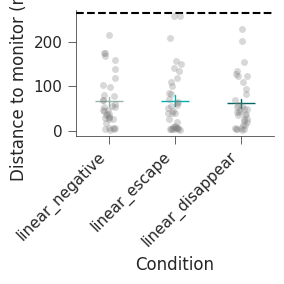

Ns, means, and  sems for data:
linear_negative: (N=35) 66.047, 9.719
linear_escape: (N=36) 67.810, 11.831
linear_disappear: (N=34) 61.819, 9.940
--- Omnibus Test Results ---
Kruskal-Wallis H-statistic: 0.2198
p-value: 0.8959

No significant differences found across conditions.


,linear_negative,linear_escape,linear_disappear
0,174.762709,156.193341,49.164693
1,28.307147,100.453967,42.858247
2,47.703147,141.748721,38.652227
3,37.263909,6.214508,21.873659
4,98.735307,3.482546,3.805616
5,6.053935,39.838752,45.801974
6,4.415418,4.656143,83.672162
7,45.297630,5.030490,5.365086
8,215.781860,207.684937,56.356651
9,69.830180,6.061181,4.798453


In [30]:
subpanel = '5o'

TimeBufferAfter = 12
TimeBufferBefore = 0
SE_colors = {'BG_negative':'#b7b7b7',
                'BG_escape':'#df5106',
                'BG_disappear':'#8A3324',
                'BG_loom':'#d42222',
                'linear_negative':'#98b5ad',
                'linear_escape':'#02b0b0',
                'linear_disappear':'#036661'}

stim_types = ['linear_negative','linear_escape','linear_disappear']

escape_data = []
for stim in stim_types:
  metadata_subset = metadata[metadata['condition'] == stim].reset_index()
  counter = 0
  data_paths = []
  for i in range(len(metadata_subset.index)):
      data_path = metadata_subset['save_path'].iloc[i]
      data = np.load(data_path, allow_pickle=True)
      fish_num, bodylength = data['fish_num'], data['f_bodylength_mm']
      exp_type, f_x, f_y = data['exp_type'], data['f_x'], data['f_y']
      EllapsedTime = data['time_stamps']
      condition = data['condition']
      ArenaDims = get_arena_dims(data)
      trial_order = ast.literal_eval(data['vid_metadata'].item()['trial order'])
      EngageThresh=float(data['vid_metadata'].item()['Engagement distance threshold'])

      # Get distance to left wall
      TopLeftX, TopLeftY = ArenaDims['Points'].values[0][0]
      BottomLeftX, BottomLeftY = ArenaDims['Points'].values[0][3]
      m = (TopLeftY - BottomLeftY) / (TopLeftX - BottomLeftX)
      b = TopLeftY - (m * TopLeftX)


      # Calculate scale
      arenaHeightPix=np.sqrt( (TopLeftX-BottomLeftX )**2 + (TopLeftY-BottomLeftY)**2)
      scale=metadata['rig_mm'].iloc[i]/ArenaDims['BBW'].values[0]
      dist2line = np.abs(m * f_x - f_y + b) / np.sqrt(m**2 + 1)

      # Get stim status and escape time stamps
      fish_escaping = data['fish_escaping']
      if sum(fish_escaping) < 10:
        print(f'Skipping fish {i} in {condition}')
        continue
      data_paths.append(data_path)
      counter +=1
      fish_showing = data['fish_showing']
      fs,fe=get_escape_data_alternating(EllapsedTime,fish_showing,fish_escaping,trial_order)
      for escape_event in range(len(fe)):
          start_time = fe['StartFishEscaping'].iloc[escape_event] - TimeBufferBefore
          end_time = fe['StartFishEscaping'].iloc[escape_event] + TimeBufferAfter
          start_idx = np.nanargmin(np.abs(EllapsedTime-start_time))#, side="left")
          end_idx = np.nanargmin(np.abs(EllapsedTime-end_time))#, side="right")
          # Calculate velocity
          f_x_filt = np.array(f_x[0,start_idx:end_idx])
          f_y_filt = np.array(f_y[0,start_idx:end_idx])
          EllapsedTime_filt = np.array(EllapsedTime[start_idx:end_idx])
          dt = np.diff(EllapsedTime_filt)
          # Put nan in front of dt array to size match
          dt = np.insert(dt, 0, np.nan)
          dt[dt==0] = np.nan
          dx = np.diff(f_x_filt)
          dx = np.insert(dx, 0, np.nan)
          dy = np.diff(f_y_filt)
          dy = np.insert(dy, 0, np.nan)
          velocity = np.sqrt(dx**2 + dy**2) / dt
          # Get distance at trigger
          escape_data.append({
              "NumEscapees": fe["NumFishEscape"].iloc[escape_event],
              "Times": EllapsedTime[start_idx:end_idx] - EllapsedTime[start_idx],
              "Distances": dist2line[0][start_idx:end_idx] * scale,
              "Velocity": velocity,
              "fish":i,
              "Condition":stim
          })
  print(f'{counter} fish included for {stim}')

# Plot average
histbin = 0.1
TotalTime = TimeBufferAfter+TimeBufferBefore
TimeBins = np.linspace(-TimeBufferBefore, TimeBufferAfter-histbin, int(TotalTime / histbin))
num_escapees = [5]
binned_data = []
for stim in stim_types:
    plot_color = SE_colors[stim]
    escape_events = [event for event in escape_data if event["Condition"] == stim]
    Times = [event["Times"] for event in escape_events]
    distances = [event["Distances"] for event in escape_events]
    conditions = [event["Condition"] for event in escape_events]

    # Get time bin indices
    bin_indices = [np.digitize(time_series, TimeBins) - 1 for time_series in Times]

    # Create distance array
    DistanceArray = np.full((len(TimeBins), len(distances)), np.nan)

    for fish_idx in range(len(distances)):
        t = Times[fish_idx]
        d = distances[fish_idx]

        if len(t) > 1:
            # Create an interpolation function for this specific fish
            f = interp1d(t, d, bounds_error=False, fill_value=np.nan)
            DistanceArray[:, fish_idx] = f(TimeBins)

    DistanceMean=np.nanmean(DistanceArray,axis=1)
    DistanceSEM=(np.nanstd(DistanceArray,axis=1)/np.sqrt(len(distances)))
    binned_data.append({'Time': TimeBins,
                        'Distance': DistanceArray,
                        'Condition': [stim] * len(DistanceArray),
                        'Data_paths': np.array(data_paths)})


## Create an SEM plot and do stats ##
StartTime = 5
EndTime = 12 #seconds after stimulus onset
bin_df = pd.DataFrame(binned_data)
bin_df = bin_df.explode(['Time', 'Distance',  'Condition'])
bin_df = bin_df.reset_index(drop=True)
plot_df = pd.DataFrame(columns=['Time', 'Distance', 'Condition'])

dfs = []
for stim in stim_types:
    bin_df_subset = bin_df[bin_df['Condition'] == stim]
    idx_start = np.searchsorted(bin_df_subset['Time'], StartTime)
    idx_end = np.searchsorted(bin_df_subset['Time'], EndTime)
    if idx_end <= idx_start:
        continue
    distances = np.stack(bin_df_subset['Distance'].iloc[idx_start:idx_end])
    median_distances = np.nanmedian(np.vstack(distances),axis=0)

    mini_df = pd.DataFrame({
        'Distance': median_distances,
        'Condition': [bin_df_subset['Condition'].iloc[0]] * len(median_distances),
        'Fish_ID': np.arange(0,len(median_distances))
    })

    dfs.append(mini_df)

plot_df = pd.concat(dfs, ignore_index=True)
condition_order = stim_types # Desired order

plt.figure(figsize=(3, 3))
ax = plt.gca()
ax.set_ylabel("Distance to monitor (mm)")

sns.stripplot(data=plot_df, x="Condition", y="Distance", order=condition_order,\
              color='gray',alpha=0.3,size=5)
sns.pointplot(data=plot_df, x="Condition", y="Distance", order=condition_order,\
              palette=SE_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);

ax.axhline(y=265,linestyle='--',color='black')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# Remove top box line and right box line
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

group_arrays = [plot_df[plot_df['Condition'] == cond]['Distance'].values for cond in condition_order]
# Remove nans from group_arrays
group_arrays = [arr[~np.isnan(arr)] for arr in group_arrays]

# stats
print("Ns, means, and  sems for data:")
for cond, data in zip(condition_order,group_arrays):
  print(f'{cond}: (N={len(data)}) {np.nanmean(data):.3f}, {scipy.stats.sem(data):.3f}')

# Run Kruskal-Wallis H-test
h_stat, p_val = stats.kruskal(*group_arrays)
print("--- Omnibus Test Results ---")
print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"p-value: {p_val:.4f}")

# 2. Post-hoc Dunn's test (If Significant)
if p_val < 0.05:
    print("\nSignificant difference found! Running Dunn's post-hoc test...")

    # Run Dunn's test with Holm-Bonferroni correction
    dunn_matrix = sp.posthoc_dunn(
        plot_df,
        val_col='Distance',
        group_col='Condition',
        p_adjust='Holm')

    # Filter and reorder the giant matrix to match your list order perfectly
    ordered_dunn = dunn_matrix.loc[condition_order, condition_order]

    print("\n--- Dunn's Post-Hoc p-values Matrix ---")
    # Display the styled matrix or just print it
    print(ordered_dunn)
else:
    print("\nNo significant differences found across conditions.")

# save source data into csv
series_dict = {}
for key, values in zip(condition_order,group_arrays):
  series_dict[f'{key}'] = pd.Series(values)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f".csv", index=False)